# Средняя носовая раковина в день операции

# Подготовка

## Настройка графики

In [1]:
# windows.options(height=5.4, width=7)
oldpar <- par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE)

require(vcd, quietly = TRUE, warn.conflicts = FALSE)
require(coin, quietly = TRUE, warn.conflicts = FALSE)
# independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE)
# HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE)
# kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE)
# for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE)
# numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE)
require(lattice, quietly = TRUE, warn.conflicts = FALSE)
require(mosaic, quietly = TRUE, warn.conflicts = FALSE)
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE)
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE)
# ggqqplot
# require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE)
# flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord


require(rstatix, quietly = TRUE)
# identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE)
# require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE)
require(repr, quietly = TRUE, warn.conflicts = FALSE)
require(knitr, quietly = TRUE, warn.conflicts = FALSE)
# Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
# sessionInfo()
# options(encoding = "UTF-8")
lor <- read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet = "данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor <- lor %>%
  dplyr::select(
    "id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация",
    "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия",
    "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
  ) %>%
  filter(локация != "полип") %>%
  filter(этап == "день операции")
lor <- as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа <- factor(lor$группа, c("ОГ", "КГ", "КГ1"))
lor$"локация" <- factor(lor$"локация")
lor$"этап" <- factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
  group_by(id, группа, локация, этап) %>%
  summarise(
    across(
      c(
        "круглоклеточная воспалительная инфильтрация",
        "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия",
        "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
      ),
      ~ median(.x, na.rm = TRUE)
    ),
    .groups = "drop"
    # mean_value = mean(measurement_value, na.rm = TRUE),
    # median_value = median(measurement_value, na.rm = TRUE),
    # sd_value = sd(measurement_value, na.rm = TRUE),
    # min_value = min(measurement_value, na.rm = TRUE),
    # max_value = max(measurement_value, na.rm = TRUE)
  ) %>%
  arrange(id)
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
lor <- lor_mean
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable <- "группа"

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname <- "круглоклеточная воспалительная инфильтрация"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

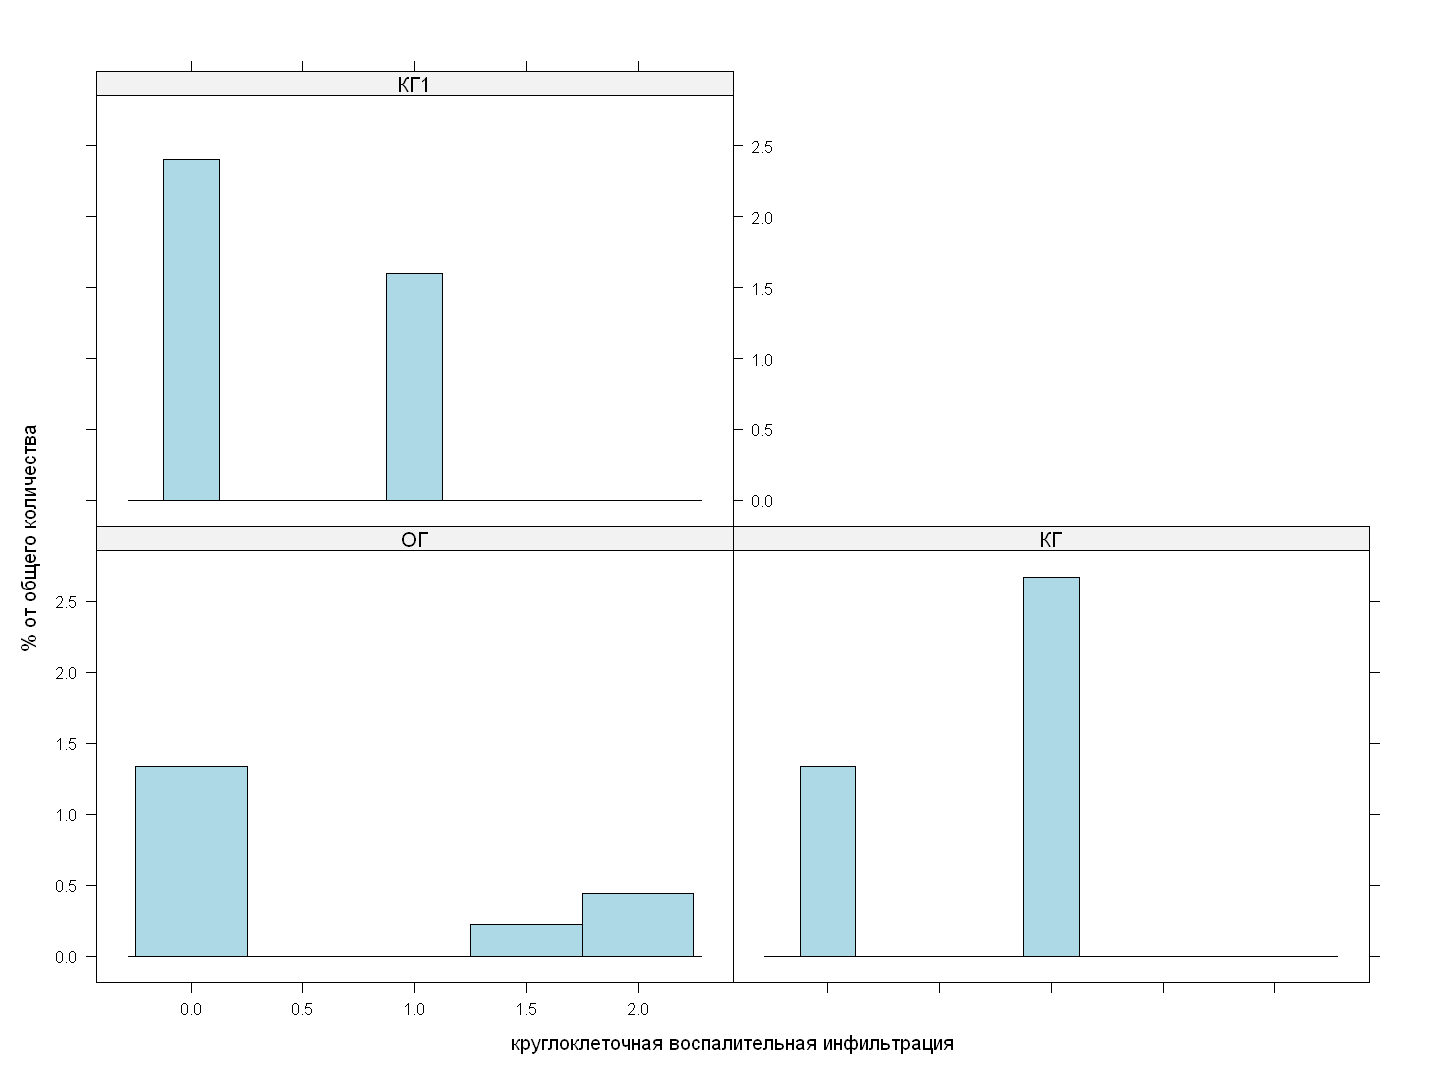

In [10]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.6111111 0.9279607 1.5  0 0.0   0 1.5    2      9
КГ  0.6666667 0.5773503 0.5  0 0.5   1 1.0    1      3
КГ1 0.4000000 0.5163978 1.0  0 0.0   0 1.0    1     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0.0,0,1.5,2,0.6111111,0.9279607,9,0
КГ,0,0.5,1,1.0,1,0.6666667,0.5773503,3,0
КГ1,0,0.0,0,1.0,1,0.4000000,0.5163978,10,0


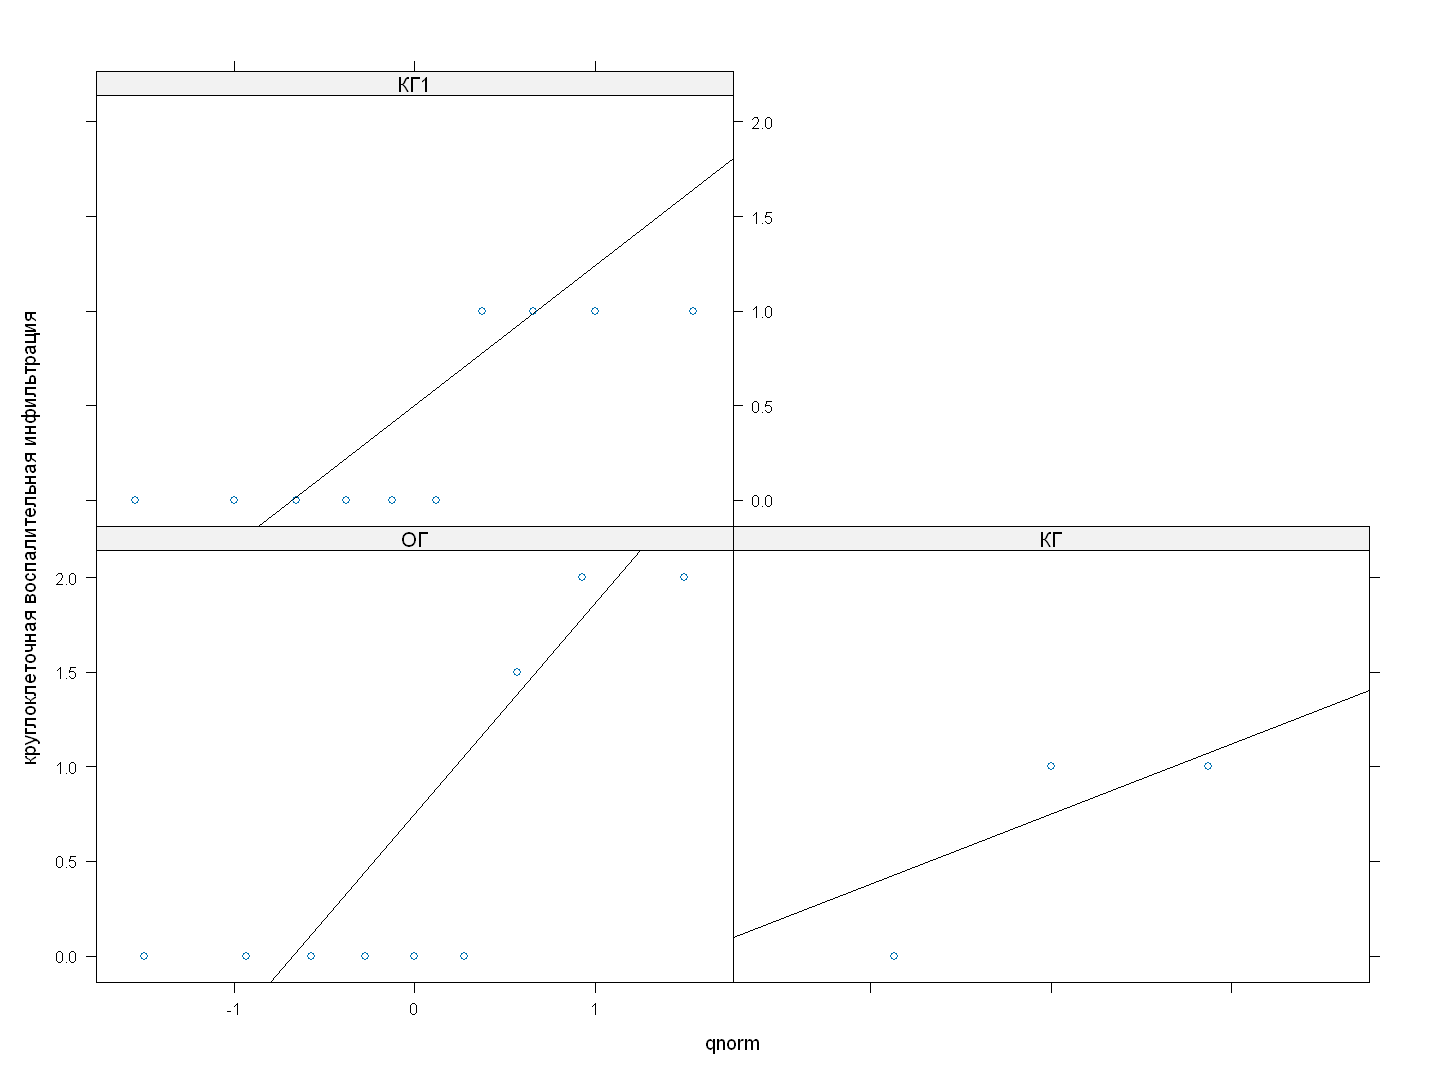

In [12]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

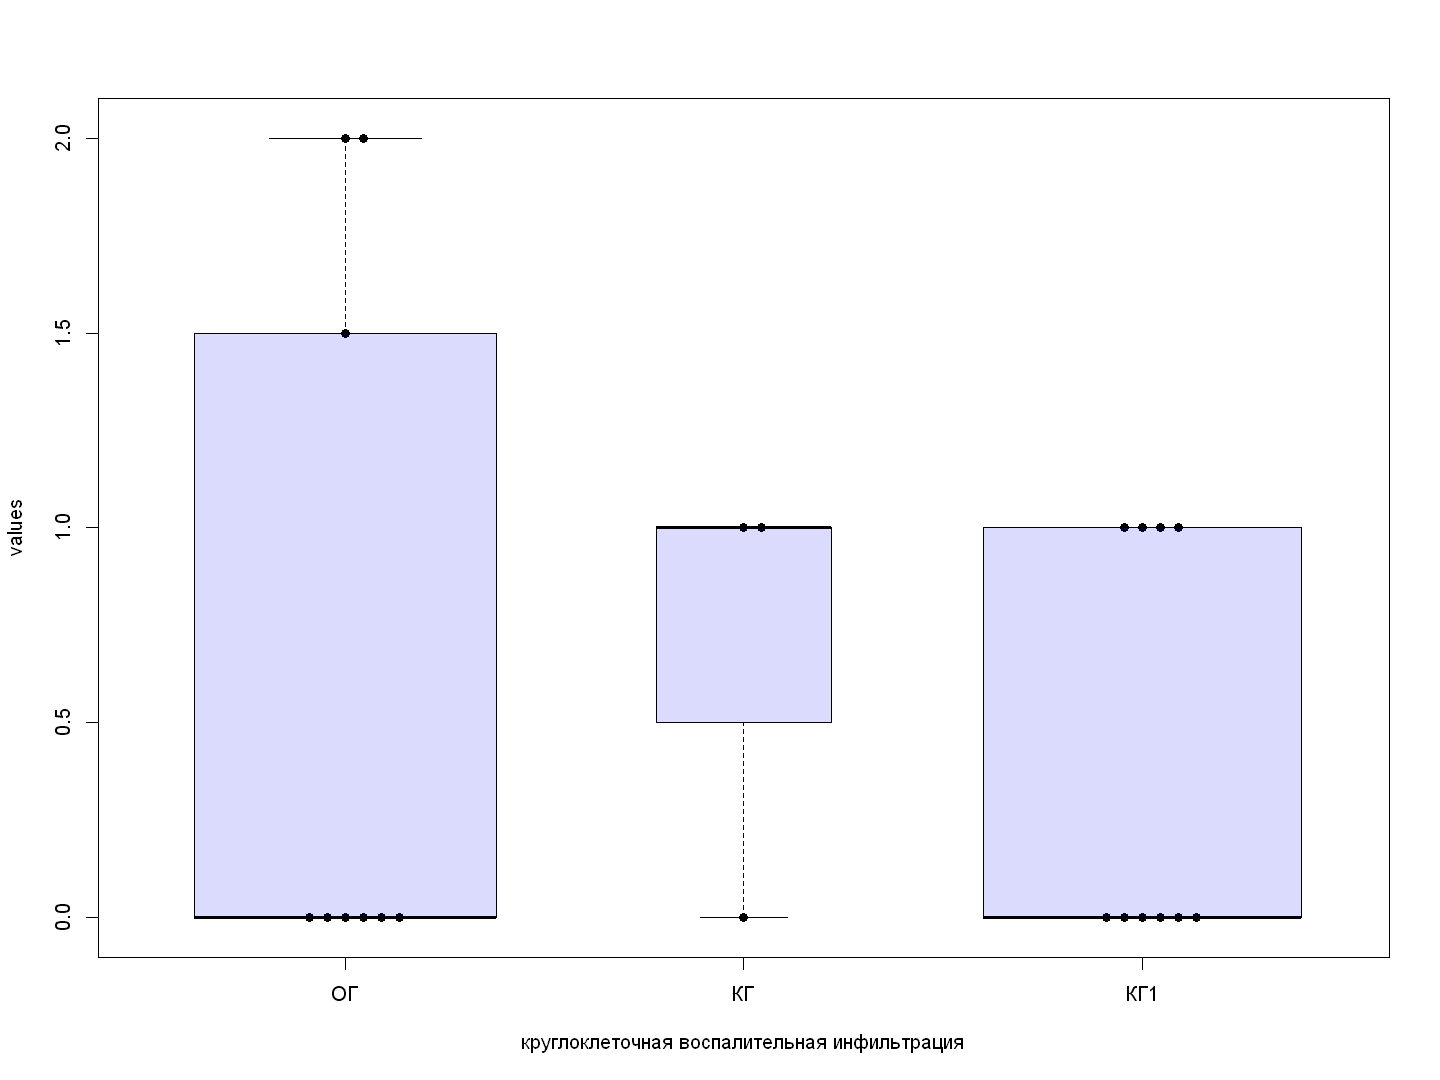

In [13]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [14]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.46667, df = 2, p-value = 0.7919

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ-КГ  1.6666667    10.363677       FALSE
ОГ-КГ1 0.8666667     7.142671       FALSE
КГ-КГ1 2.5333333    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 12, p-value = 0.8359
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -0.31063, p-value = 0.8091
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 48, p-value = 0.8124
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

da

## бокаловидные клетки

### Общее

In [15]:
parname <- "бокаловидные клетки"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [16]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [17]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

    mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ   0.0 0.0000000 0.00  0   0   0 0.00    0      9
КГ   0.0 0.0000000 0.00  0   0   0 0.00    0      3
КГ1  0.4 0.6992059 0.75  0   0   0 0.75    2     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0.00,0,0.0,0.0000000,9,0
КГ,0,0,0,0.00,0,0.0,0.0000000,3,0
КГ1,0,0,0,0.75,2,0.4,0.6992059,10,0


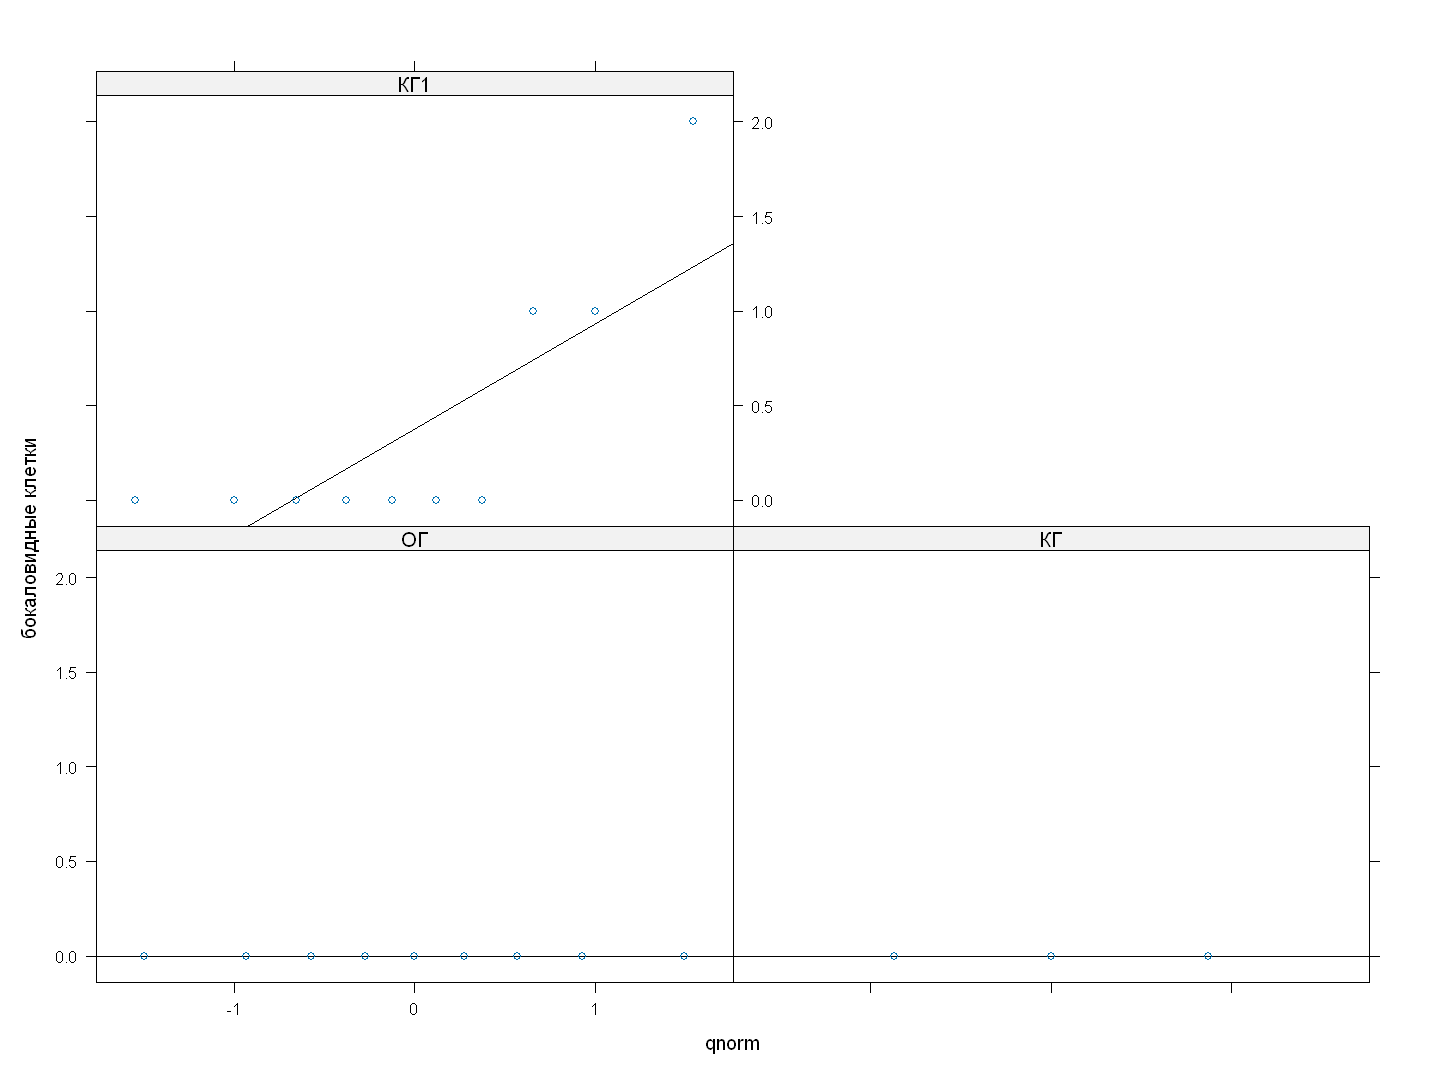

In [18]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

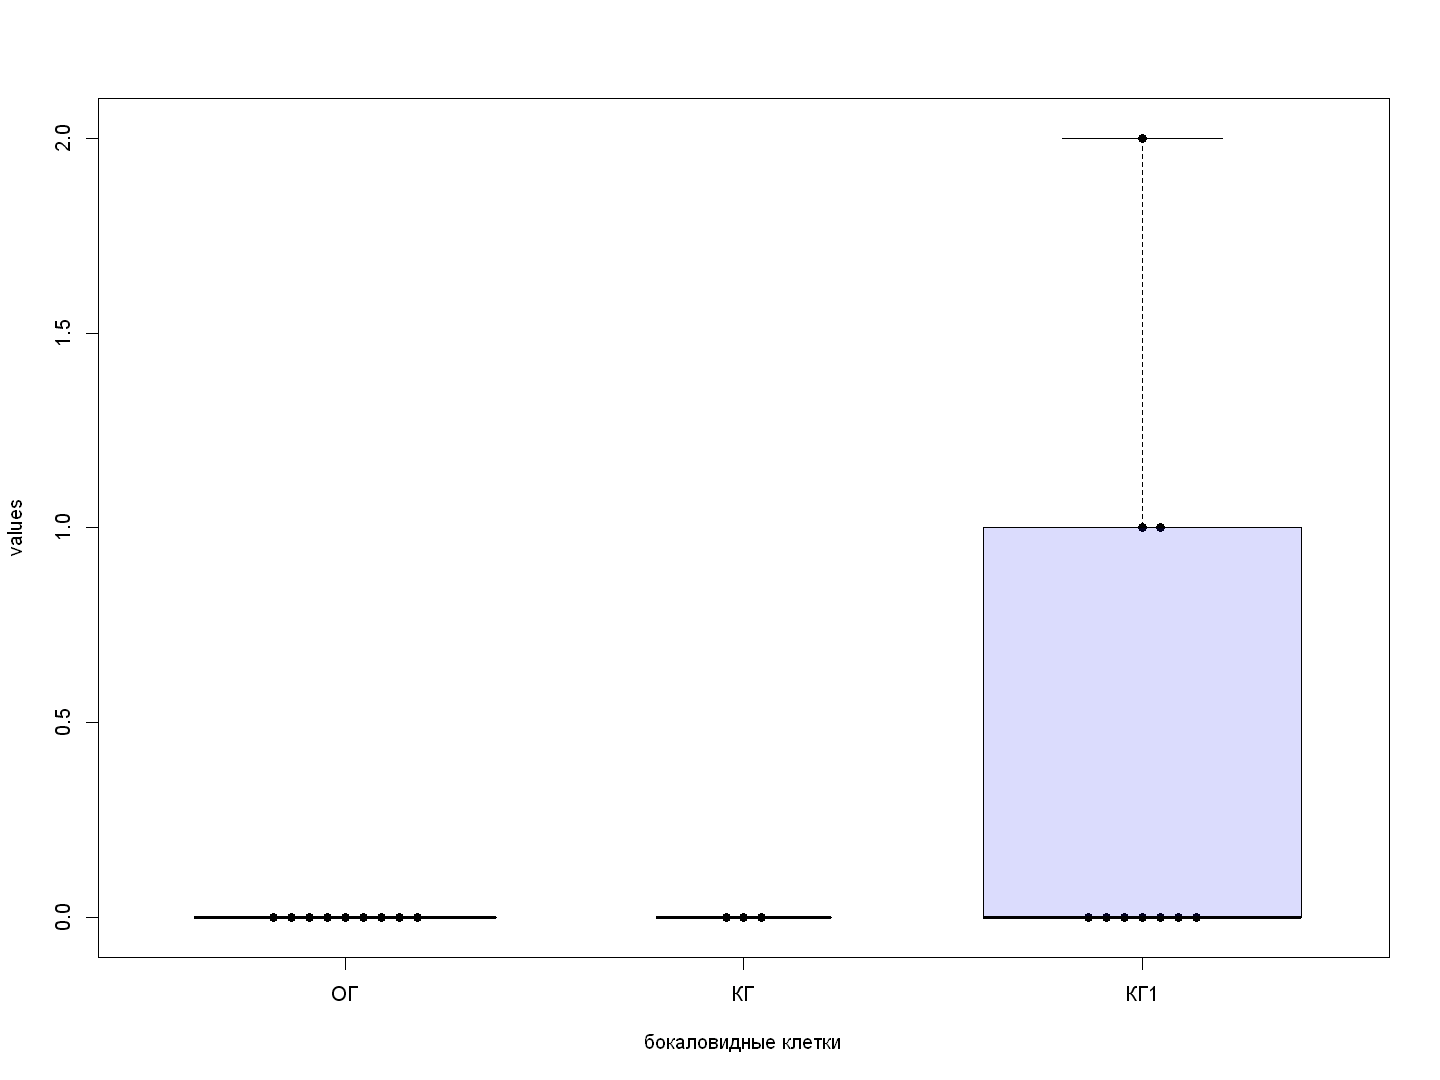

In [19]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [20]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 3.96, df = 2, p-value = 0.1381

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
       obs.dif critical.dif stat.signif
ОГ-КГ      0.0    10.363677       FALSE
ОГ-КГ1     3.3     7.142671       FALSE
КГ-КГ1     3.3    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 13.5, p-value = NA
alternative hypothesis: true location shift is not equal to 0

Error in if (q == 0) 1L else sum(Prob[T %LE% if (q < 0) q else -q]) +  : 
  missing value where TRUE/FALSE needed

Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 31.5, p-value = 0.09437
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ1

## отек

### Общее

In [21]:
parname <- "отек"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

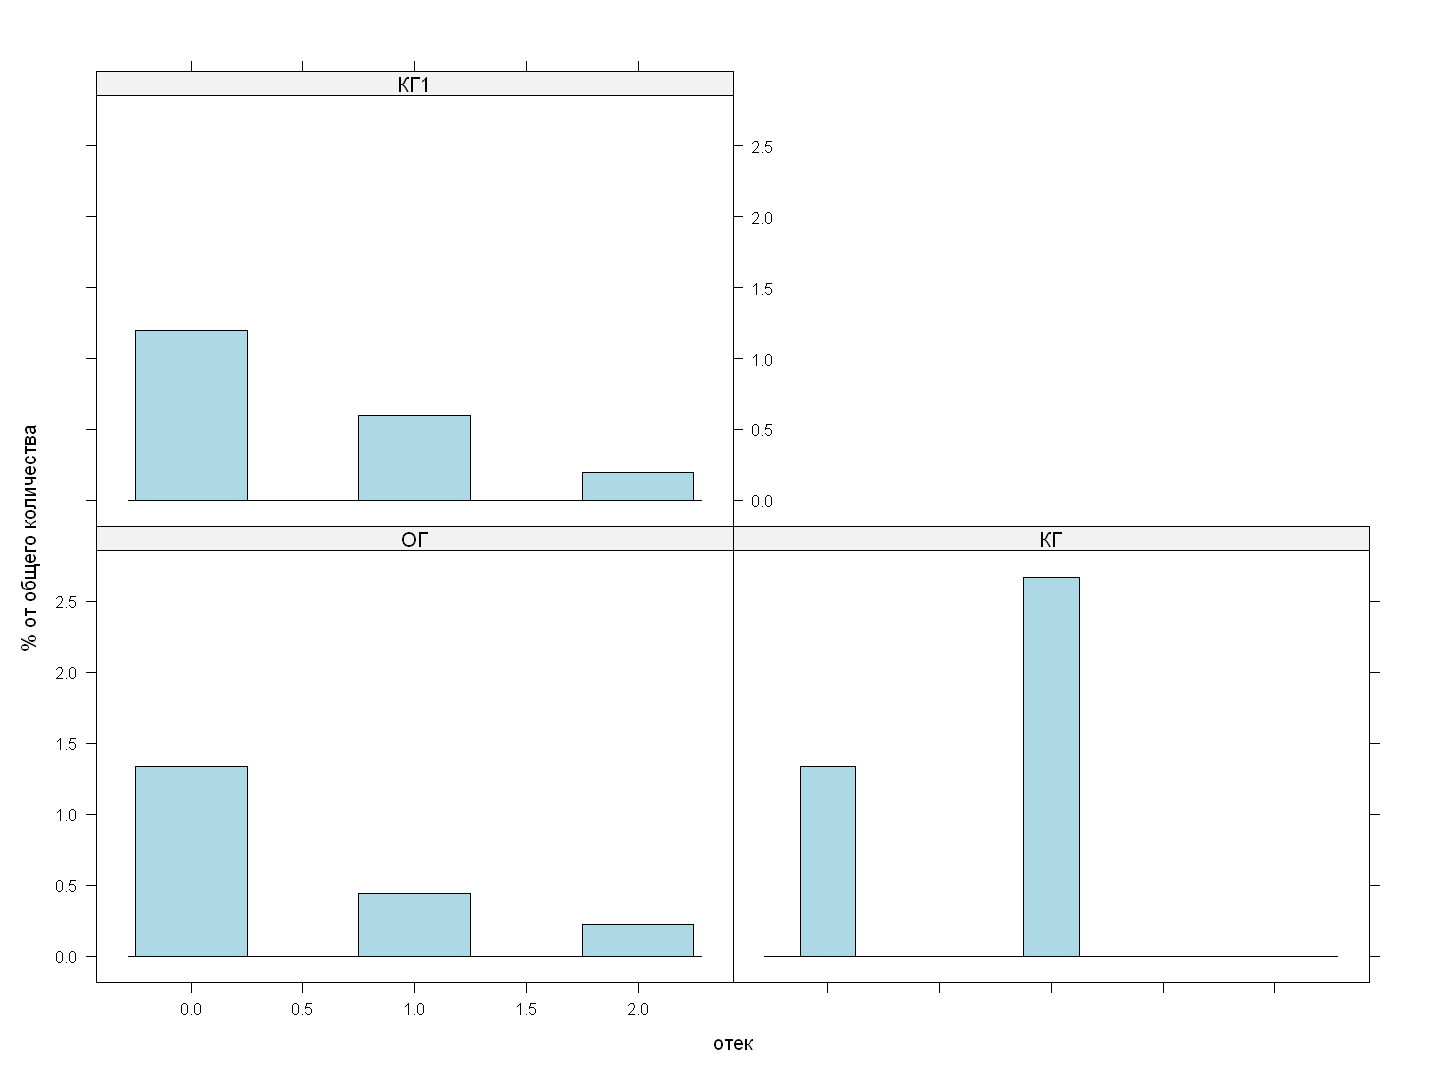

In [22]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [23]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.4444444 0.7264832 1.0  0 0.0   0   1    2      9
КГ  0.6666667 0.5773503 0.5  0 0.5   1   1    1      3
КГ1 0.5000000 0.7071068 1.0  0 0.0   0   1    2     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0.0,0,1,2,0.4444444,0.7264832,9,0
КГ,0,0.5,1,1,1,0.6666667,0.5773503,3,0
КГ1,0,0.0,0,1,2,0.5000000,0.7071068,10,0


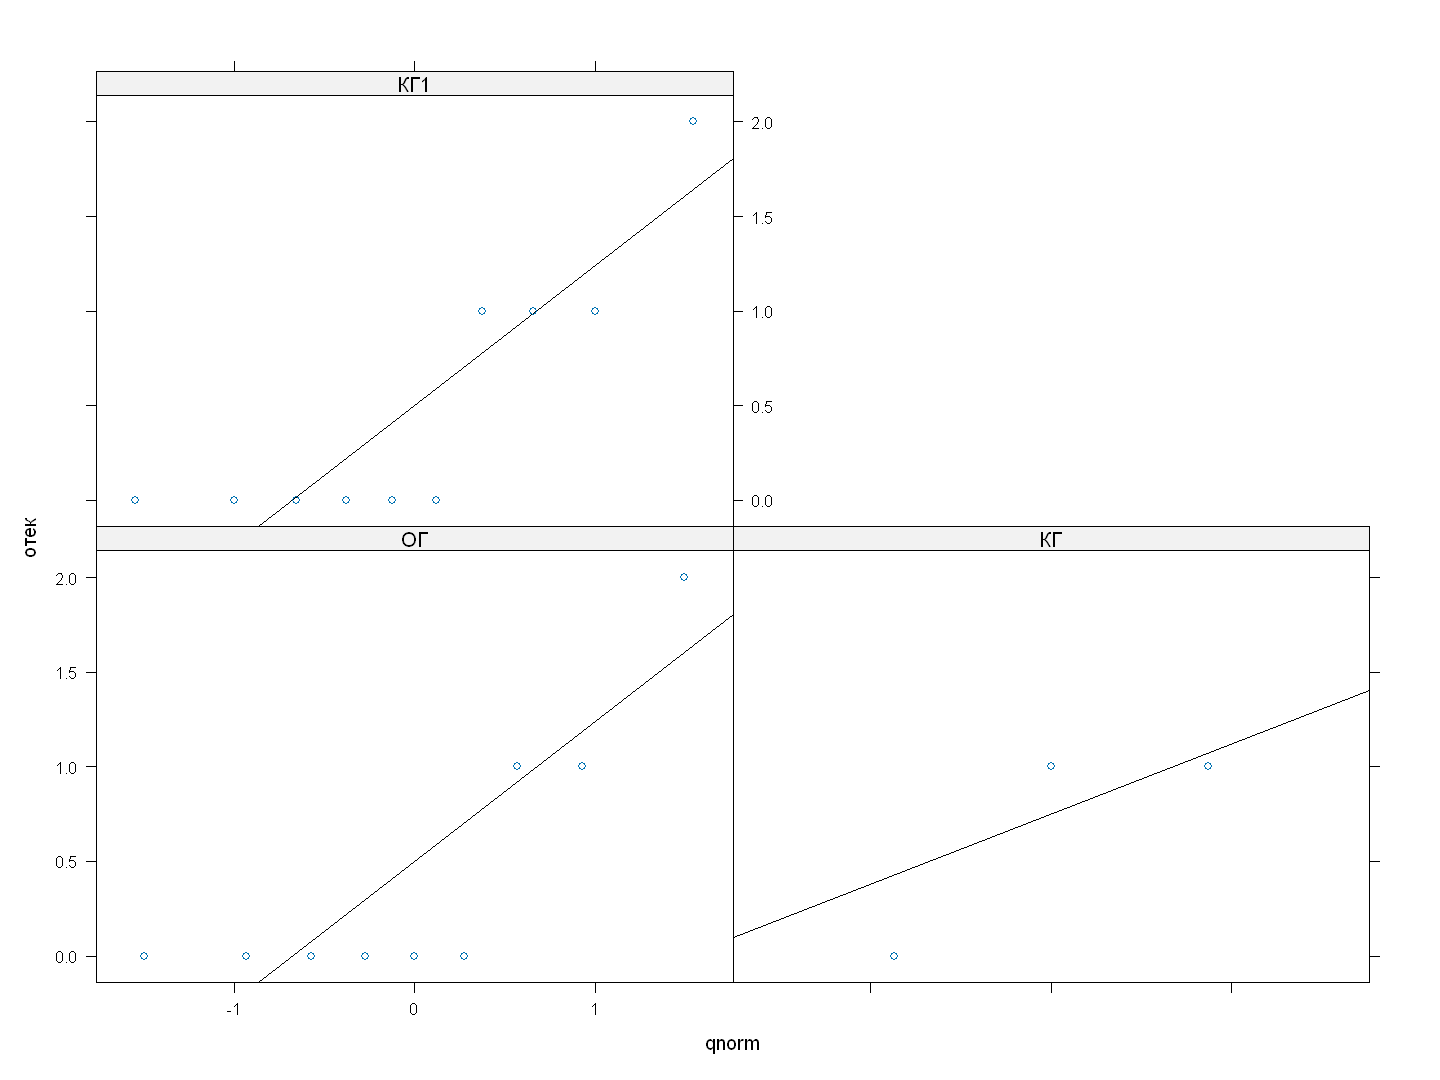

In [24]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

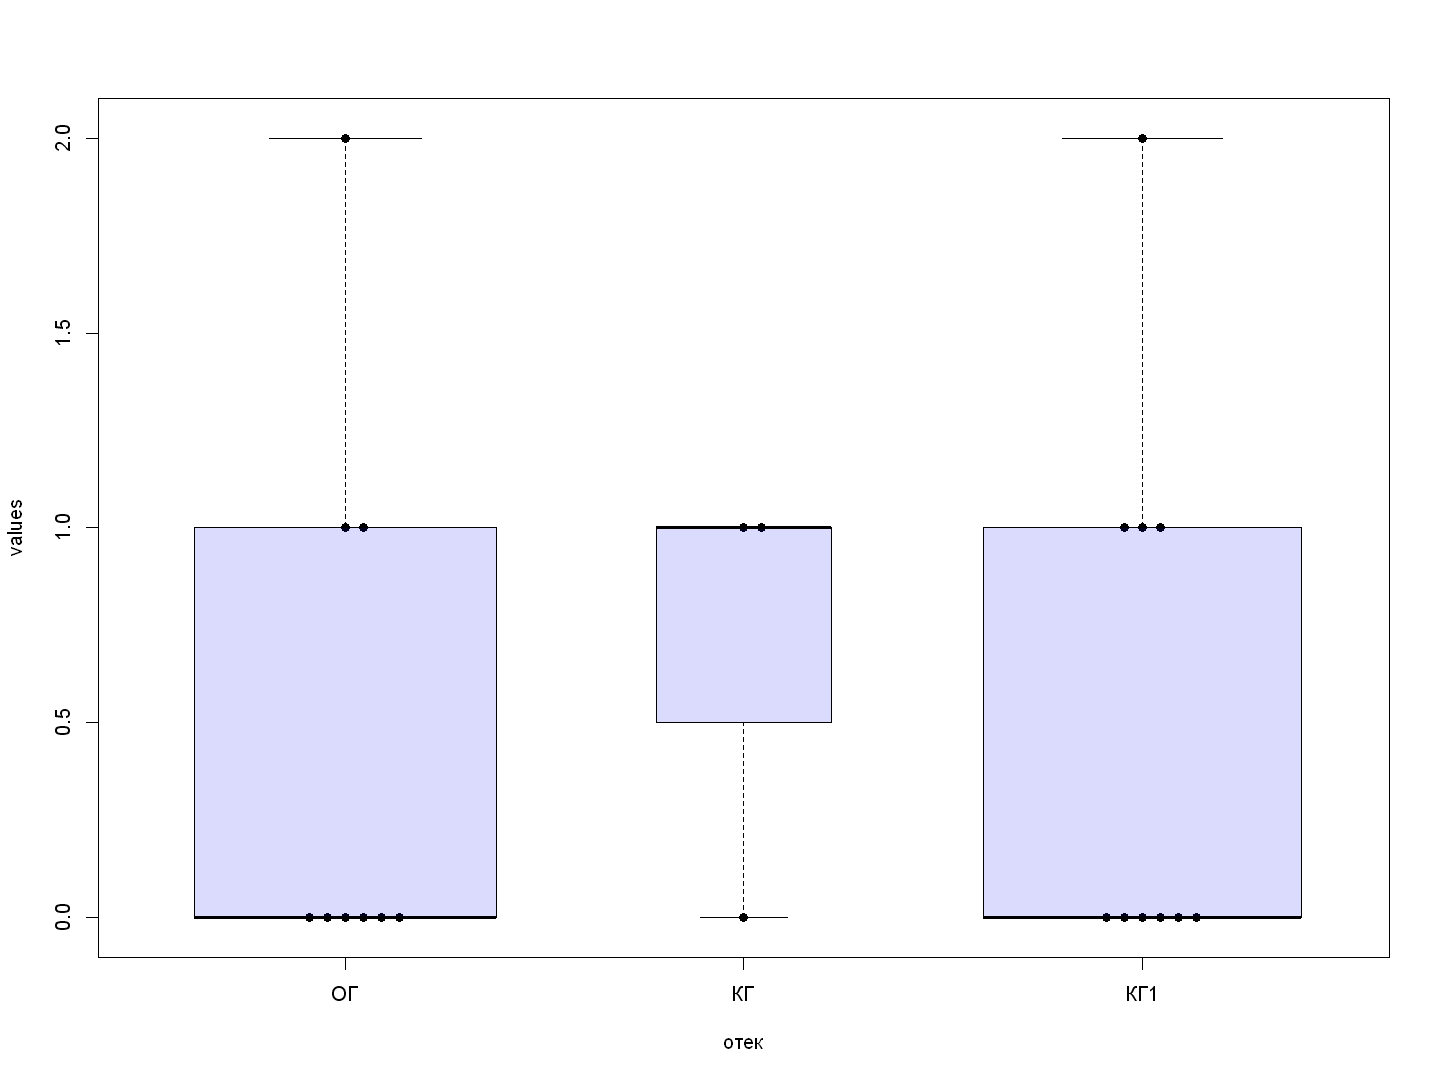

In [25]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [26]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.56337, df = 2, p-value = 0.7545

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ-КГ  2.8333333    10.363677       FALSE
ОГ-КГ1 0.6166667     7.142671       FALSE
КГ-КГ1 2.2166667    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 10, p-value = 0.5271
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -0.73786, p-value = 0.5227
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 42.5, p-value = 0.8485
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test



## реснички эпителия

### Общее

In [27]:
parname <- "реснички эпителия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

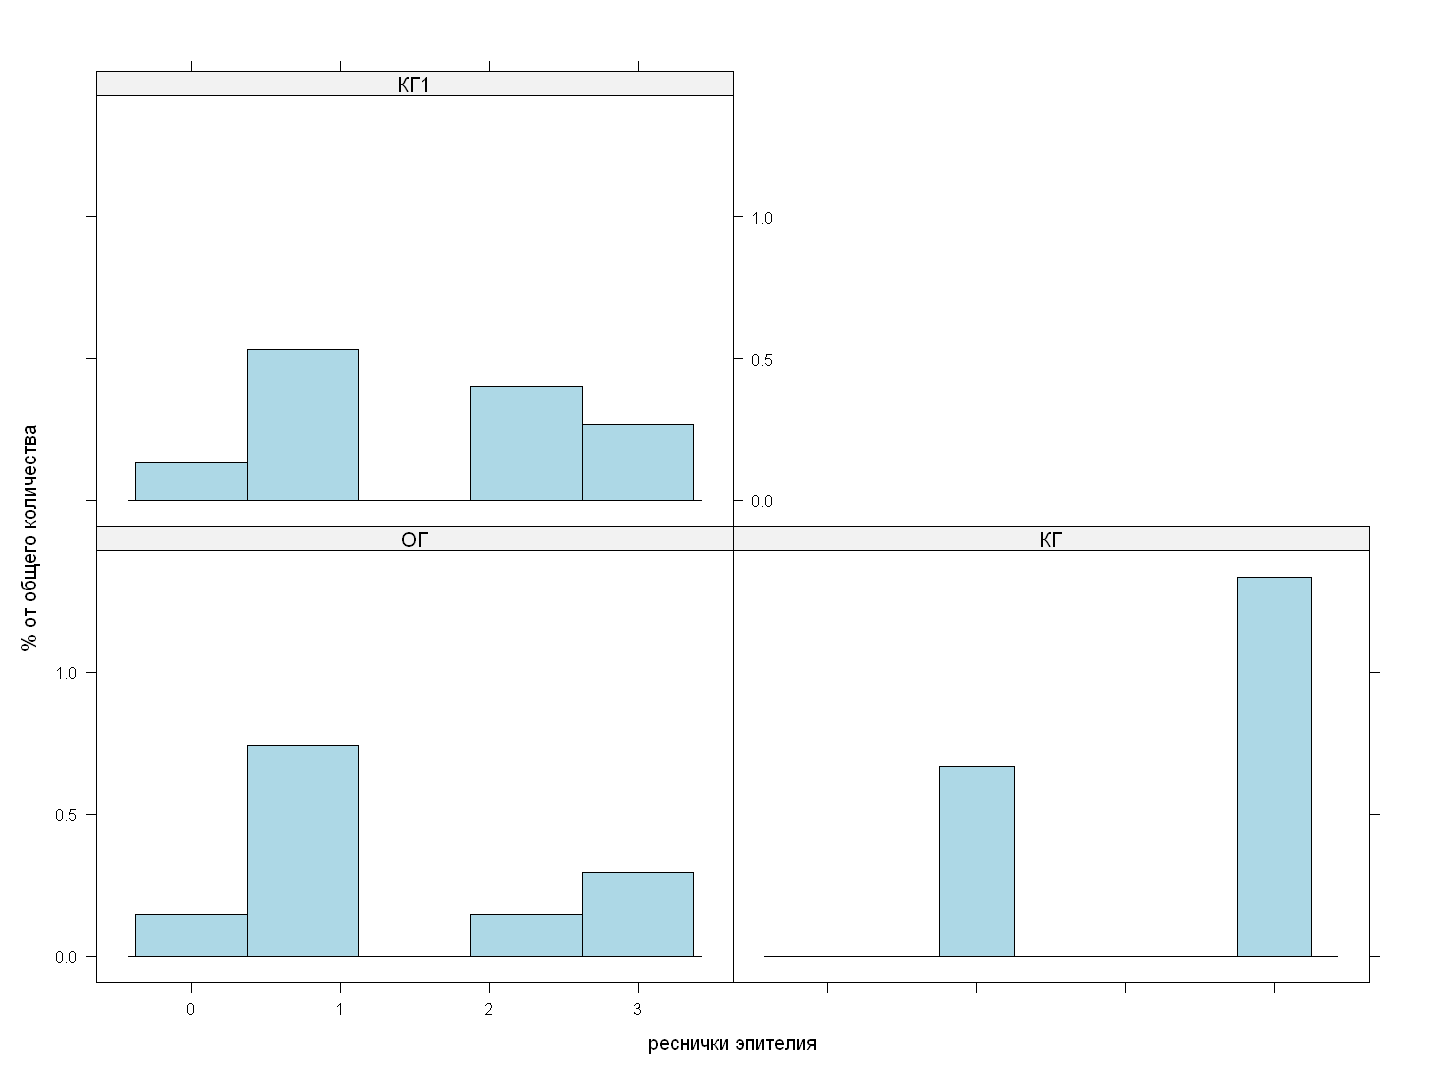

In [28]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [29]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  1.500000 1.0606602 1.5  0   1 1.0 2.5    3      9
КГ  2.333333 1.1547005 1.0  1   2 3.0 3.0    3      3
КГ1 1.600000 0.9660918 1.0  0   1 1.5 2.0    3     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1,1.0,2.5,3,1.500000,1.0606602,9,0
КГ,1,2,3.0,3.0,3,2.333333,1.1547005,3,0
КГ1,0,1,1.5,2.0,3,1.600000,0.9660918,10,0


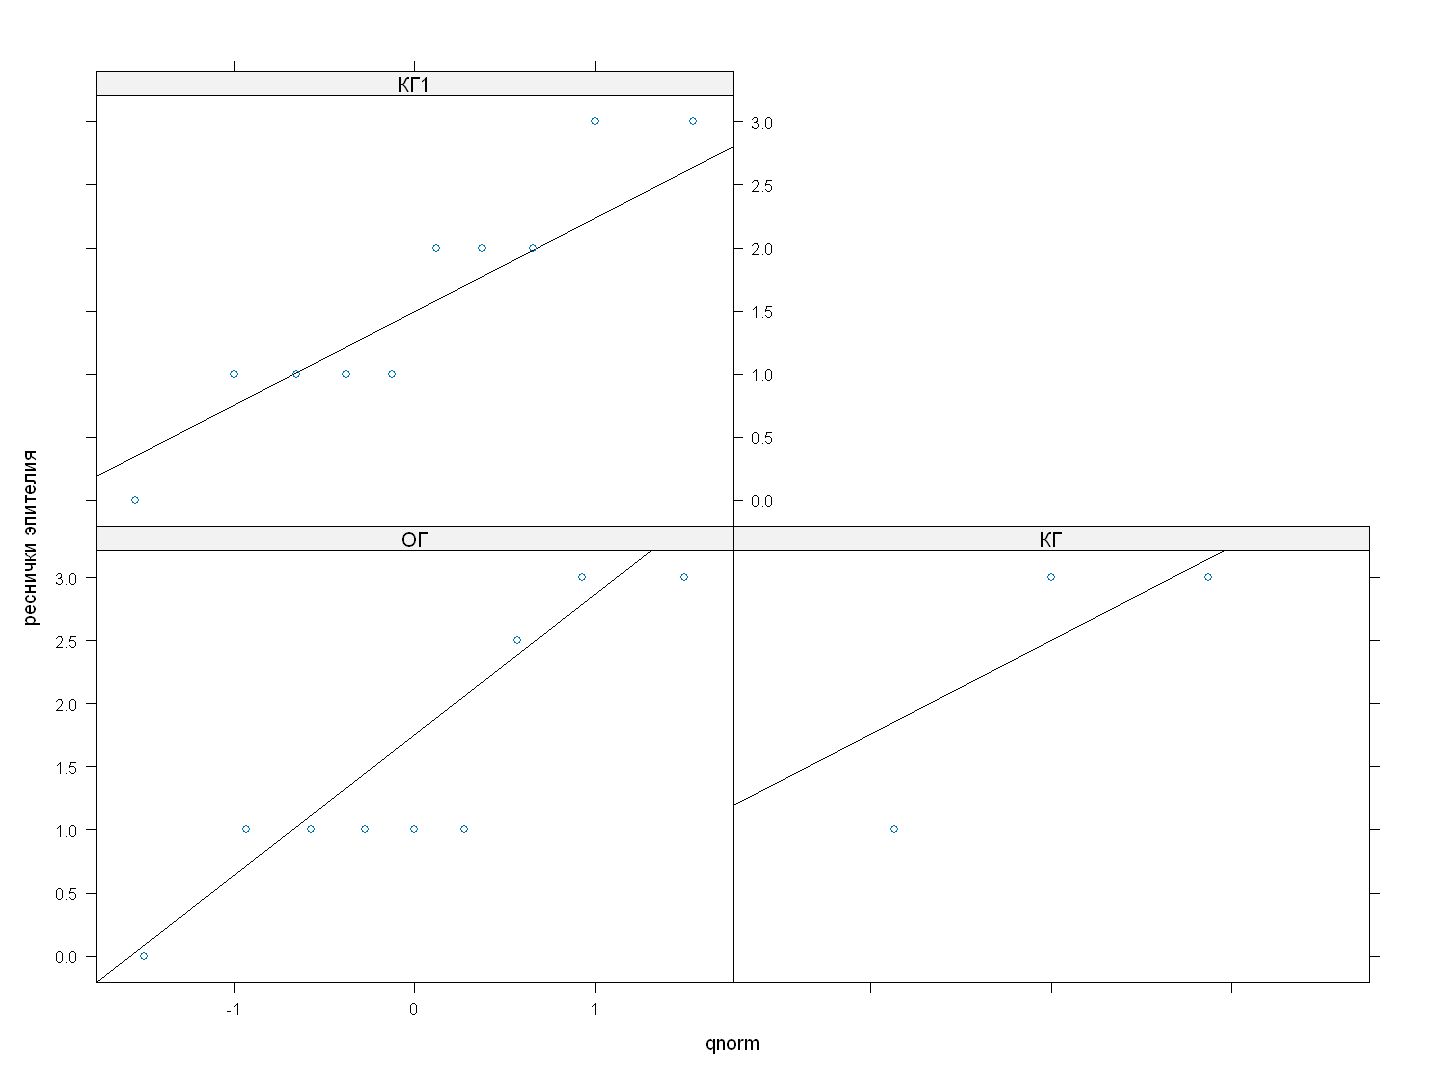

In [30]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

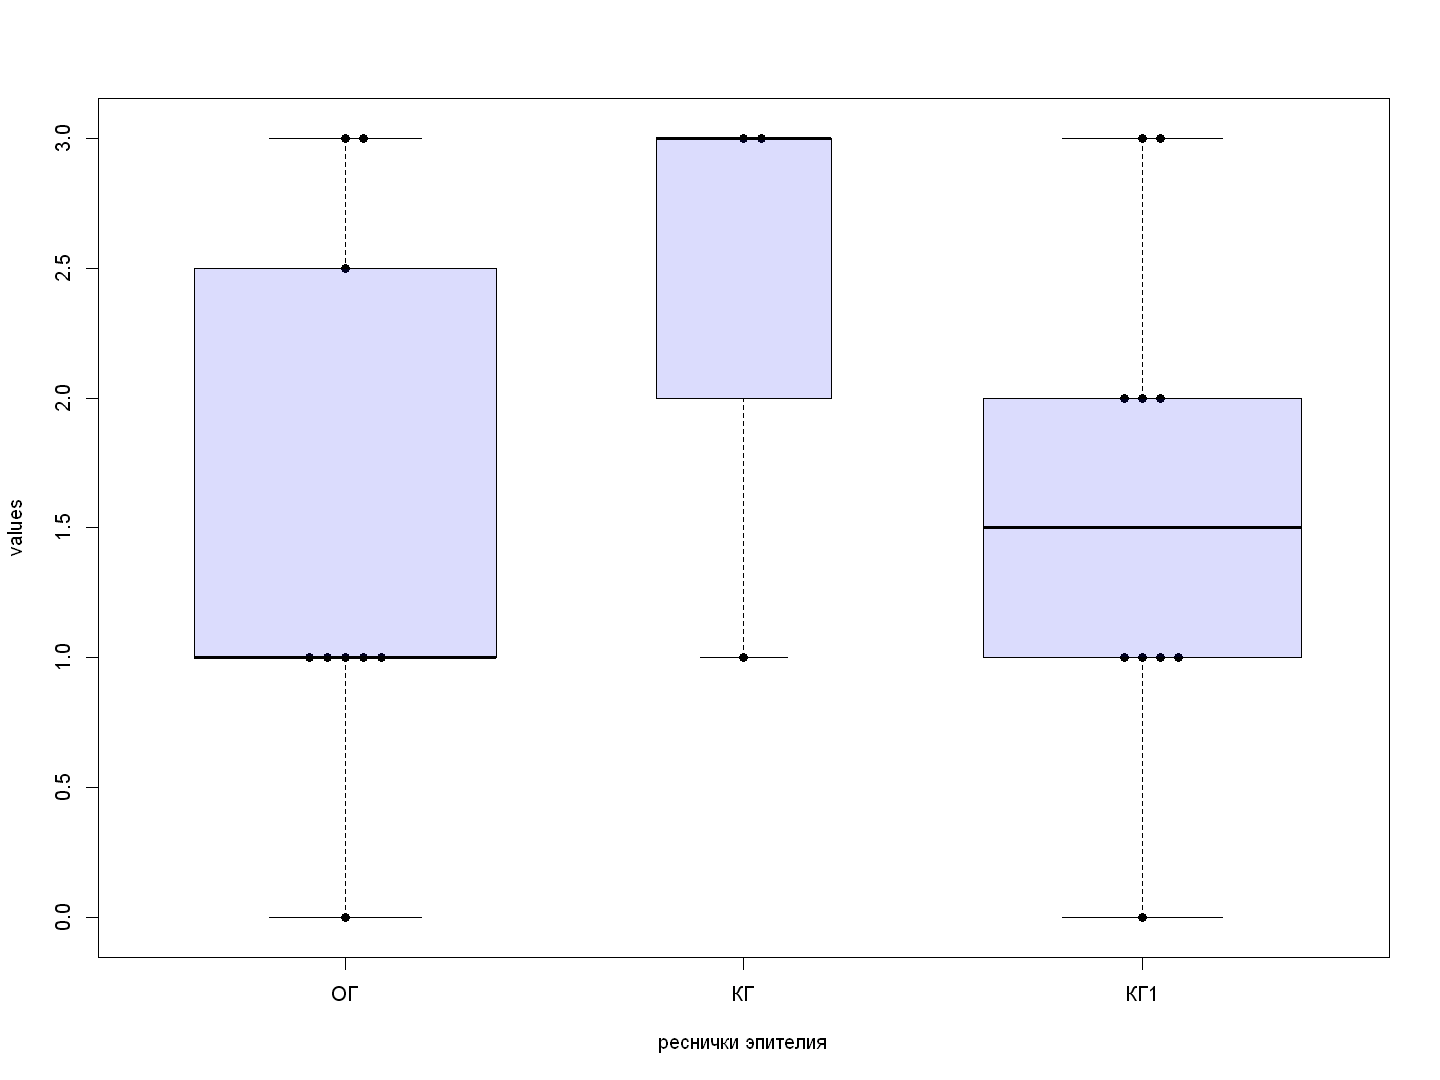

In [31]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [32]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.5731, df = 2, p-value = 0.4554

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ-КГ  5.0555556    10.363677       FALSE
ОГ-КГ1 0.8055556     7.142671       FALSE
КГ-КГ1 4.2500000    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 7.5, p-value = 0.2679
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -1.2085, p-value = 0.3955
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 41.5, p-value = 0.7942
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

d

## фиброз

### Общее

In [33]:
parname <- "фиброз"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

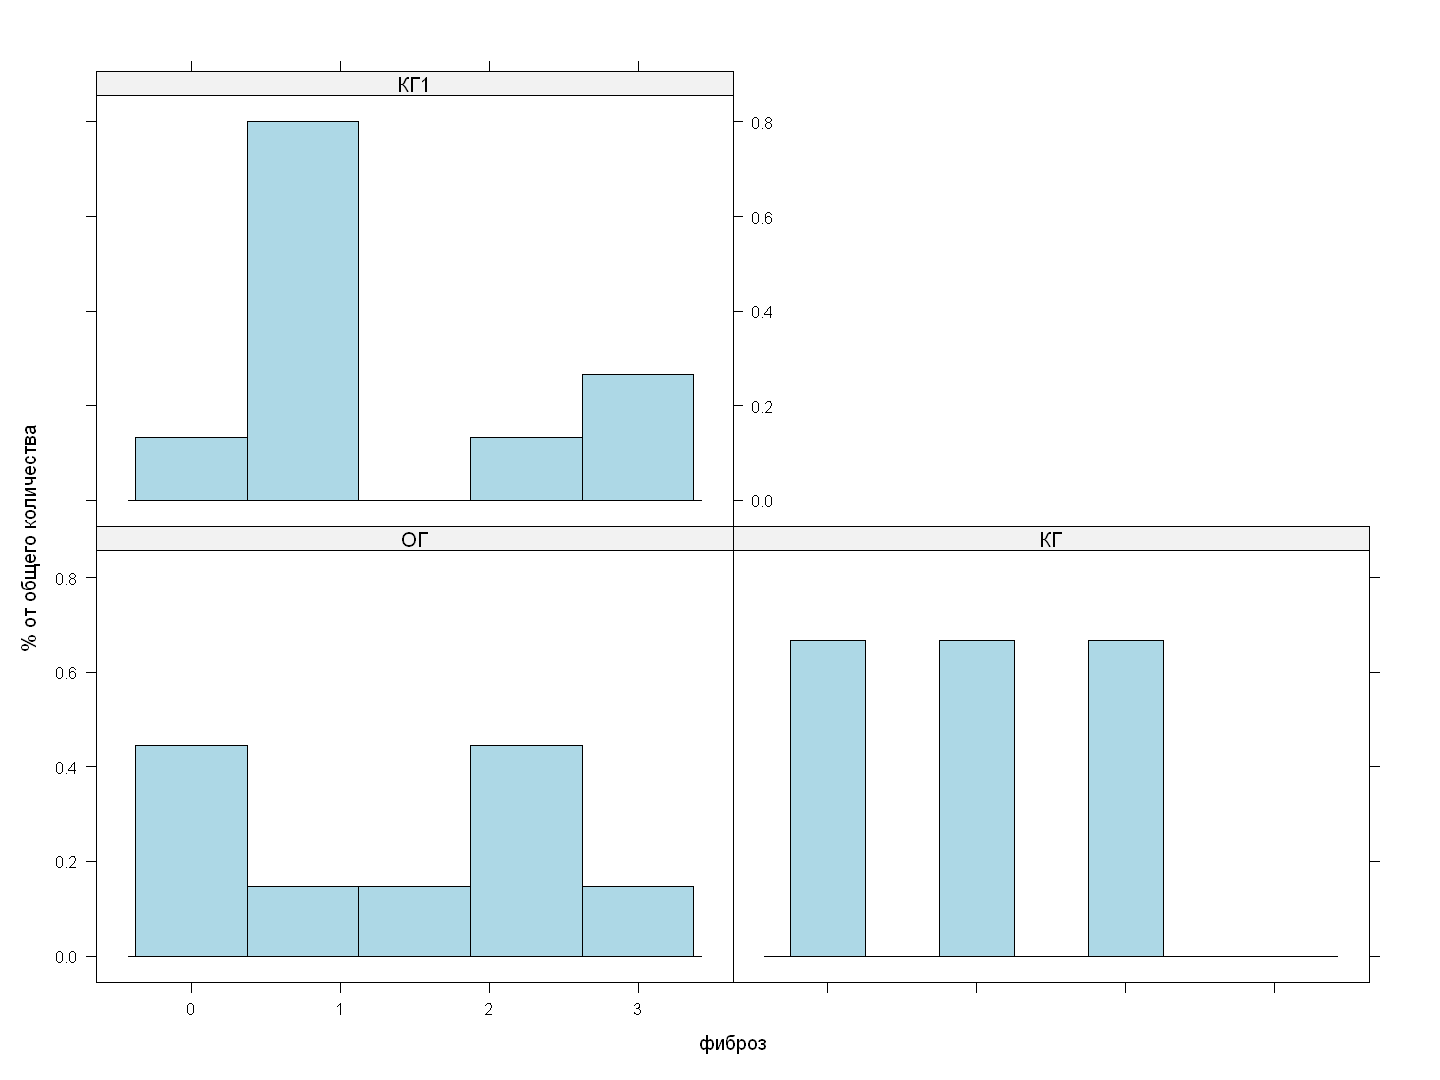

In [34]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [35]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ  1.277778 1.0929064 2.00  0 0.0 1.5 2.00    3      9
КГ  1.000000 1.0000000 1.00  0 0.5 1.0 1.50    2      3
КГ1 1.400000 0.9660918 0.75  0 1.0 1.0 1.75    3     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0.0,1.5,2.00,3,1.277778,1.0929064,9,0
КГ,0,0.5,1.0,1.50,2,1.000000,1.0000000,3,0
КГ1,0,1.0,1.0,1.75,3,1.400000,0.9660918,10,0


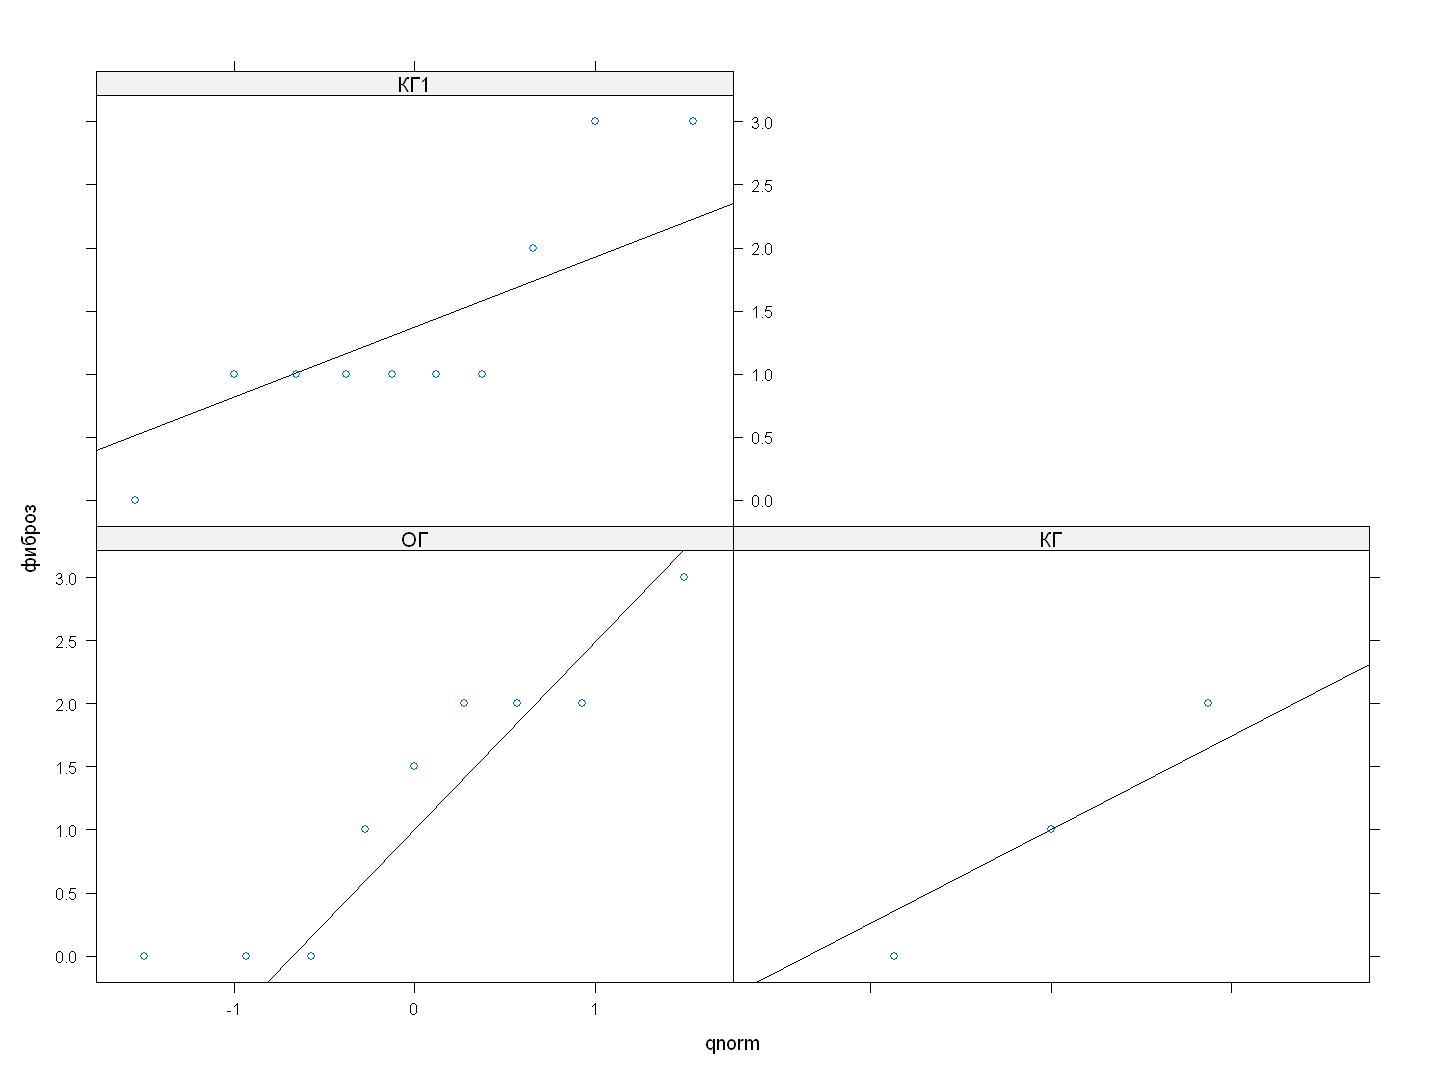

In [36]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

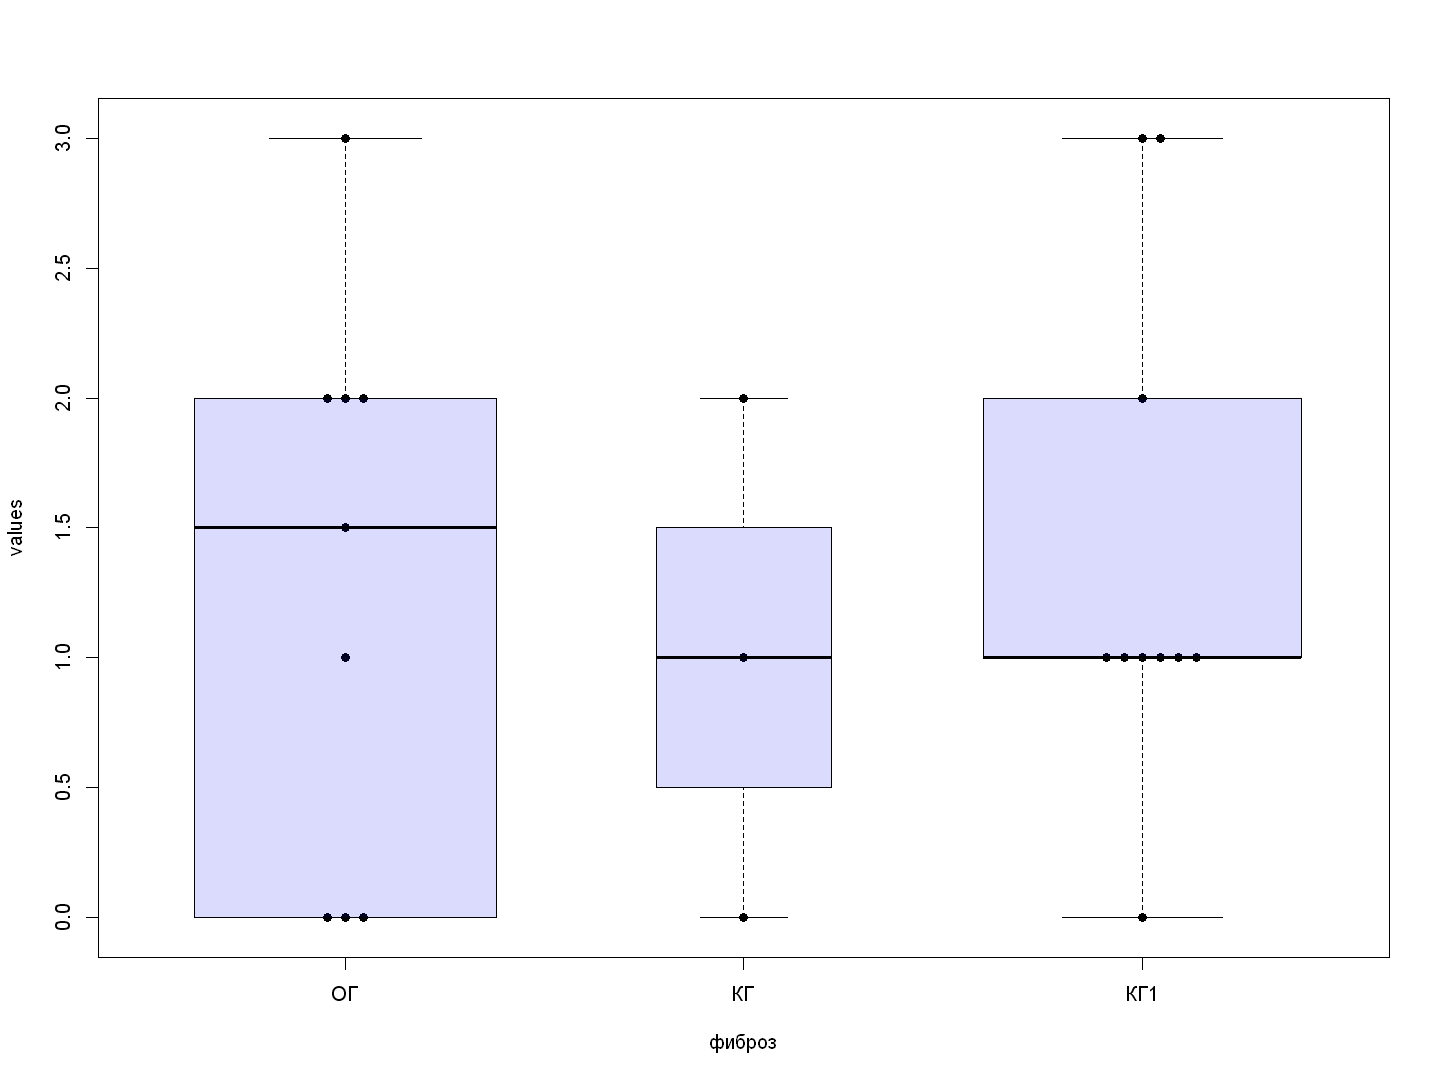

In [37]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [38]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.25677, df = 2, p-value = 0.8795

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ-КГ  1.7777778    10.363677       FALSE
ОГ-КГ1 0.2888889     7.142671       FALSE
КГ-КГ1 2.0666667    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 15.5, p-value = 0.7732
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 0.38417, p-value = 0.8682
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 44, p-value = 0.9662
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

d

## гиперплазия респираторного эпителия

### Общее

In [39]:
parname <- "гиперплазия респираторного эпителия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

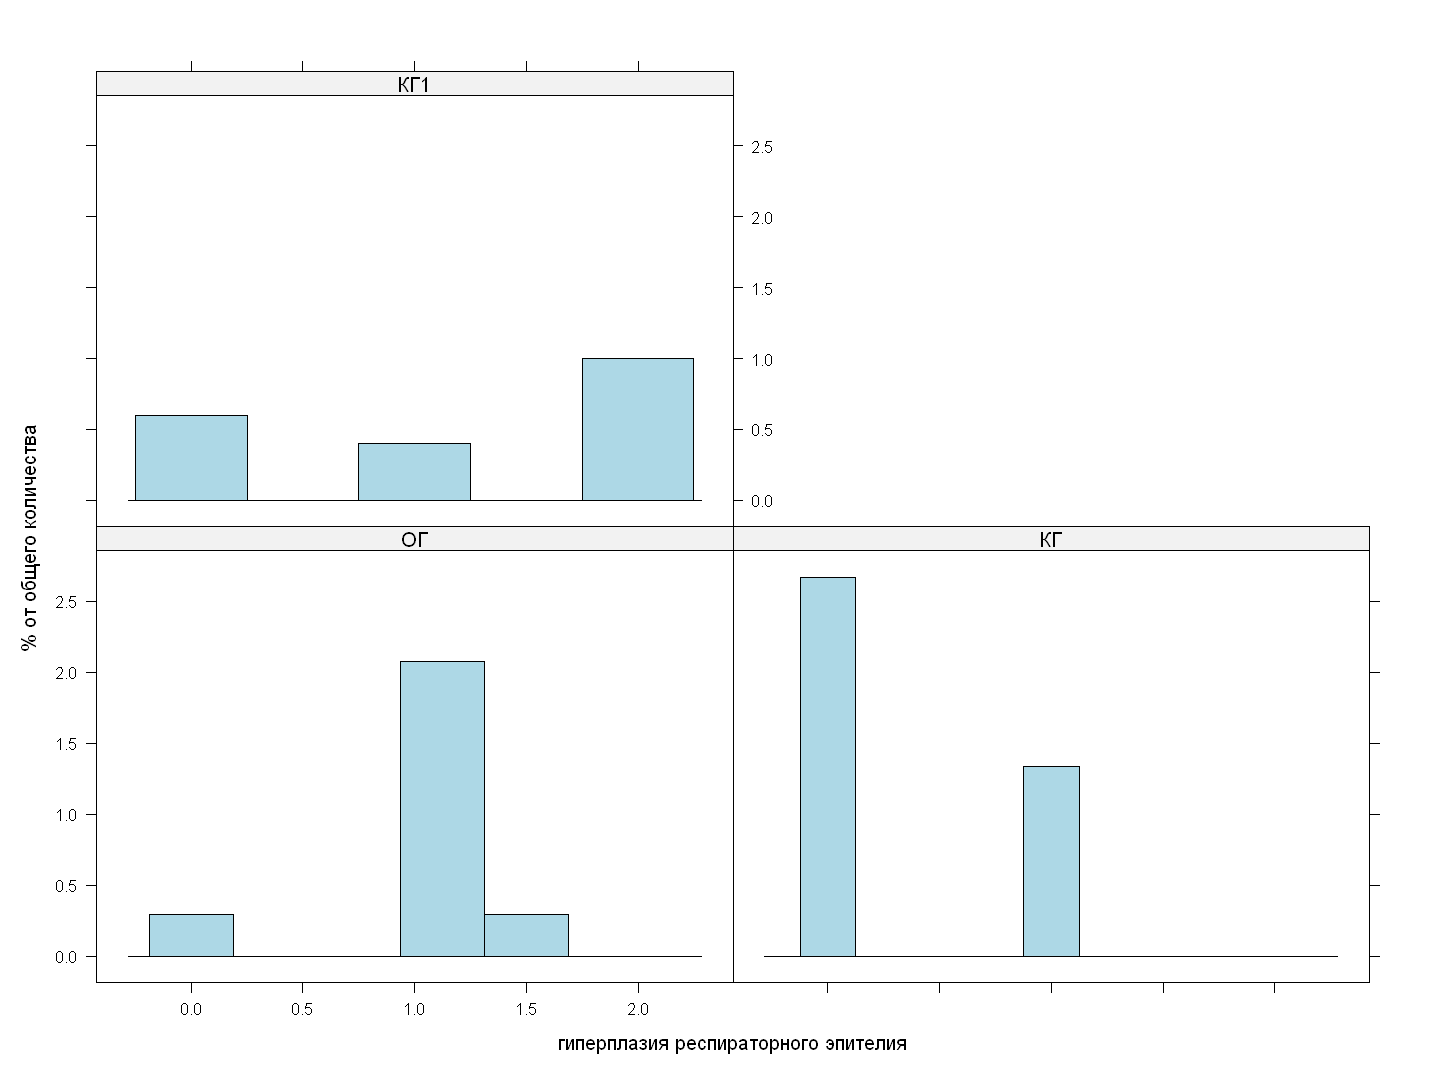

In [40]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd  IQR 0%  25% 50% 75% 100% data:n
ОГ  0.9444444 0.3908680 0.00  0 1.00 1.0 1.0  1.5      9
КГ  0.3333333 0.5773503 0.50  0 0.00 0.0 0.5  1.0      3
КГ1 1.2000000 0.9189366 1.75  0 0.25 1.5 2.0  2.0     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1.00,1.0,1.0,1.5,0.9444444,0.3908680,9,0
КГ,0,0.00,0.0,0.5,1.0,0.3333333,0.5773503,3,0
КГ1,0,0.25,1.5,2.0,2.0,1.2000000,0.9189366,10,0


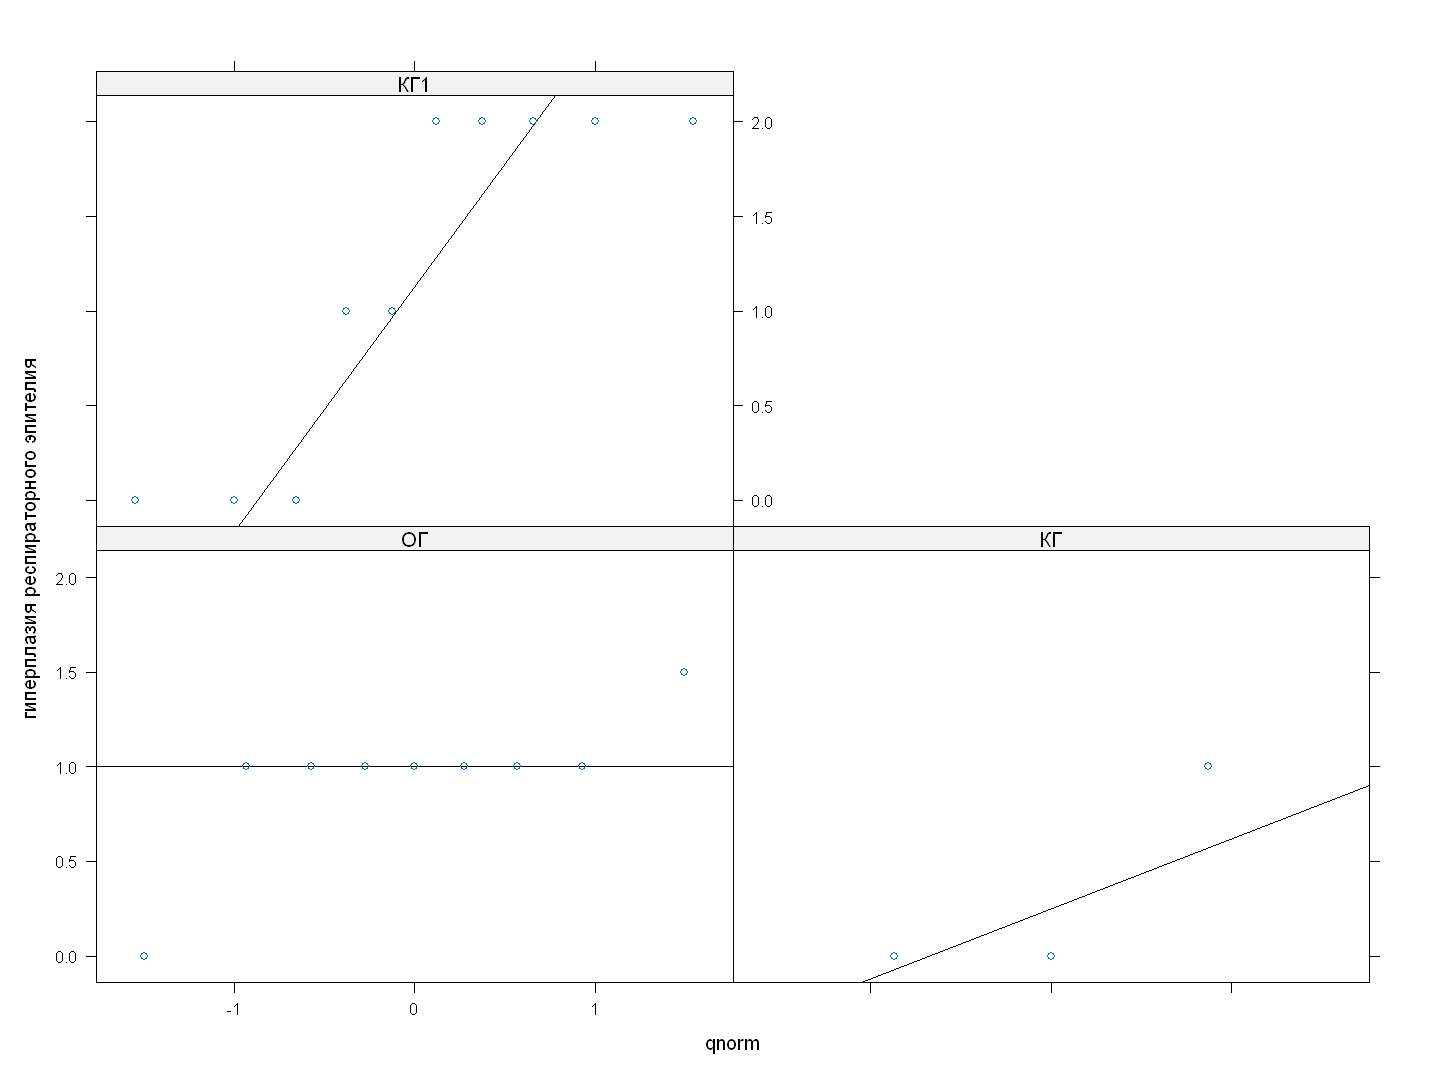

In [42]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

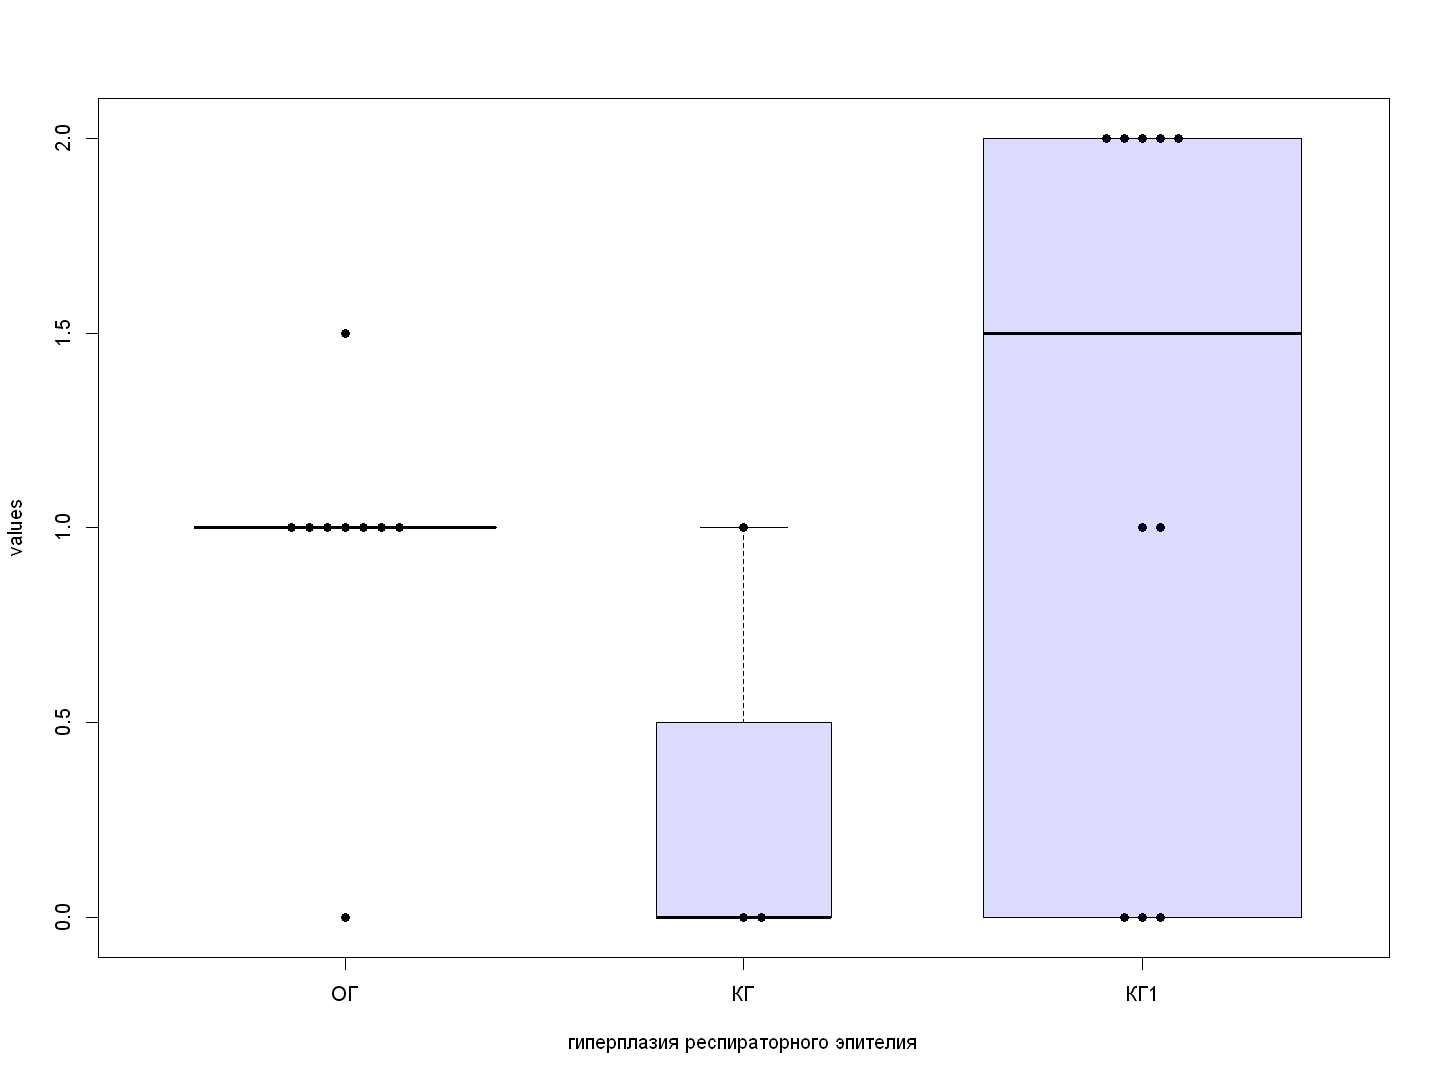

In [43]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [44]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 3.2564, df = 2, p-value = 0.1963

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  5.055556    10.363677       FALSE
ОГ-КГ1 2.127778     7.142671       FALSE
КГ-КГ1 7.183333    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 21.5, p-value = 0.09558
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 1.7778, p-value = 0.1136
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 34.5, p-value = 0.3809
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data

## плоскоклеточная метаплазия

### Общее

In [45]:
parname <- "плоскоклеточная метаплазия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

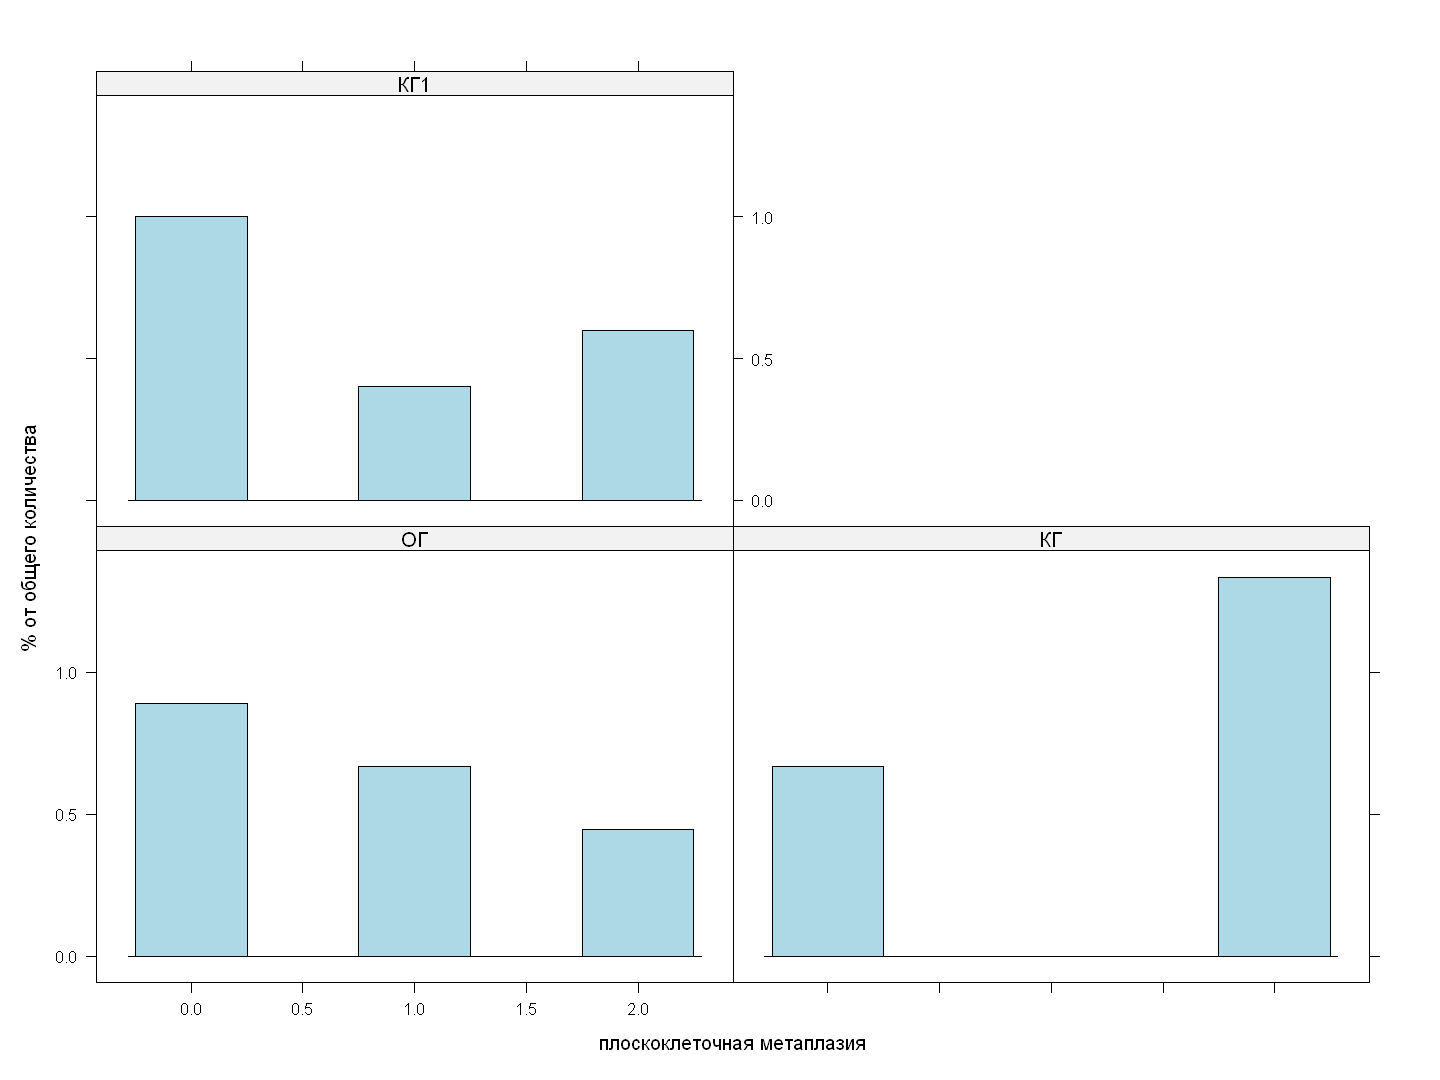

In [46]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [47]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ  0.7777778 0.8333333 1.00  0   0 1.0 1.00    2      9
КГ  1.3333333 1.1547005 1.00  0   1 2.0 2.00    2      3
КГ1 0.8000000 0.9189366 1.75  0   0 0.5 1.75    2     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,1.0,1.00,2,0.7777778,0.8333333,9,0
КГ,0,1,2.0,2.00,2,1.3333333,1.1547005,3,0
КГ1,0,0,0.5,1.75,2,0.8000000,0.9189366,10,0


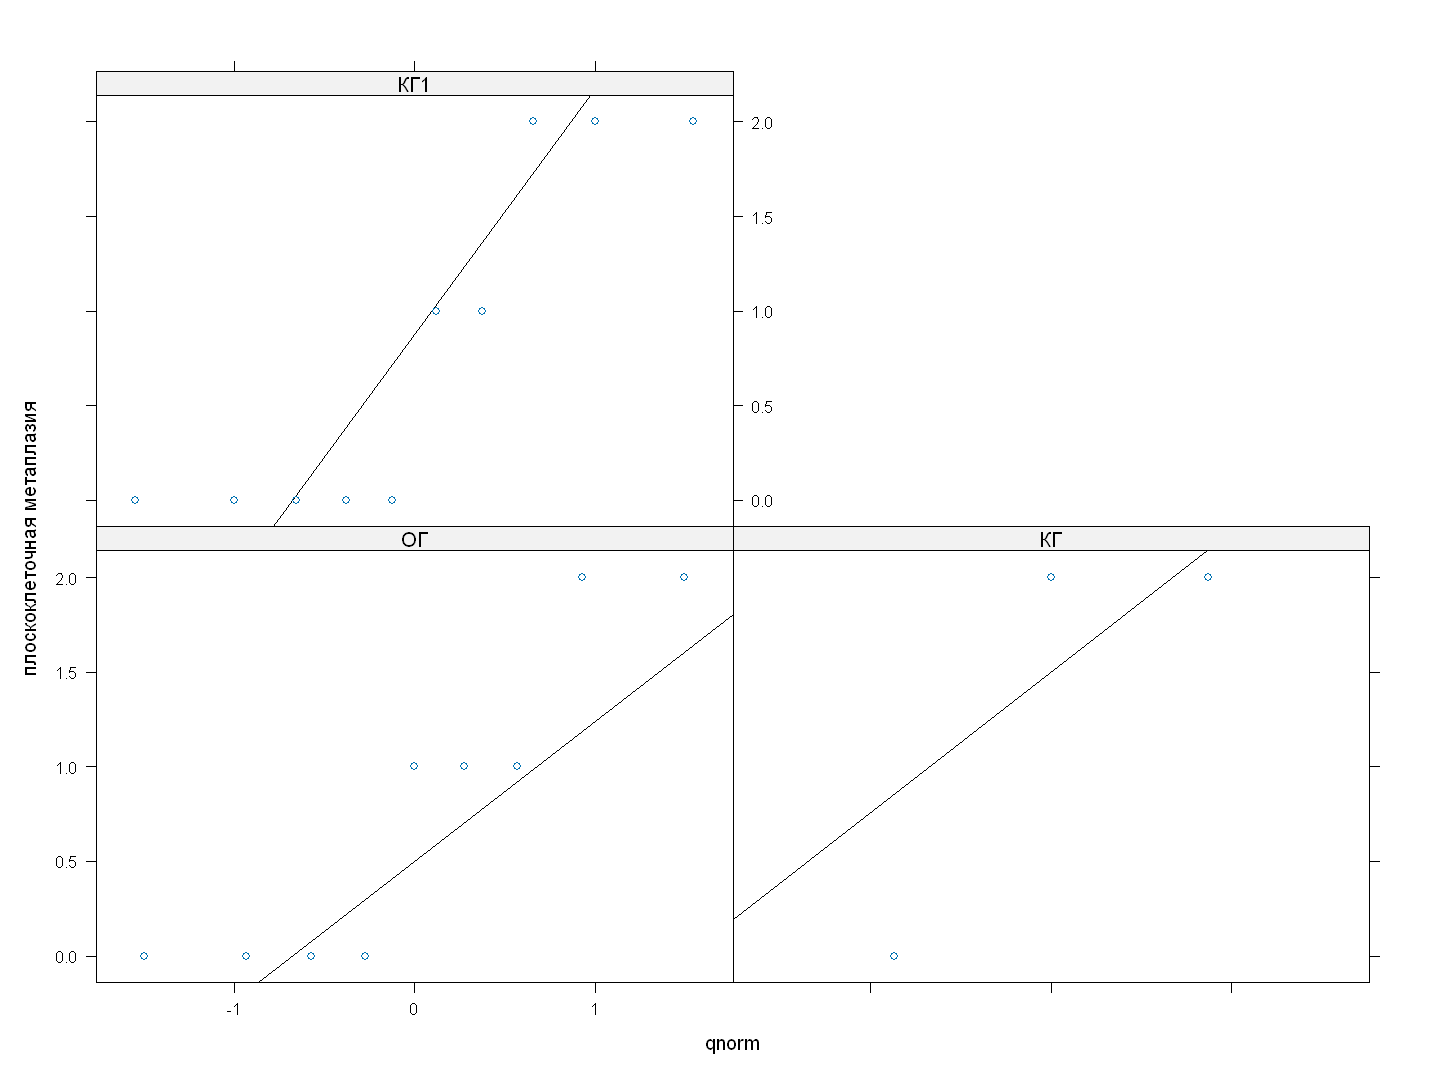

In [48]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

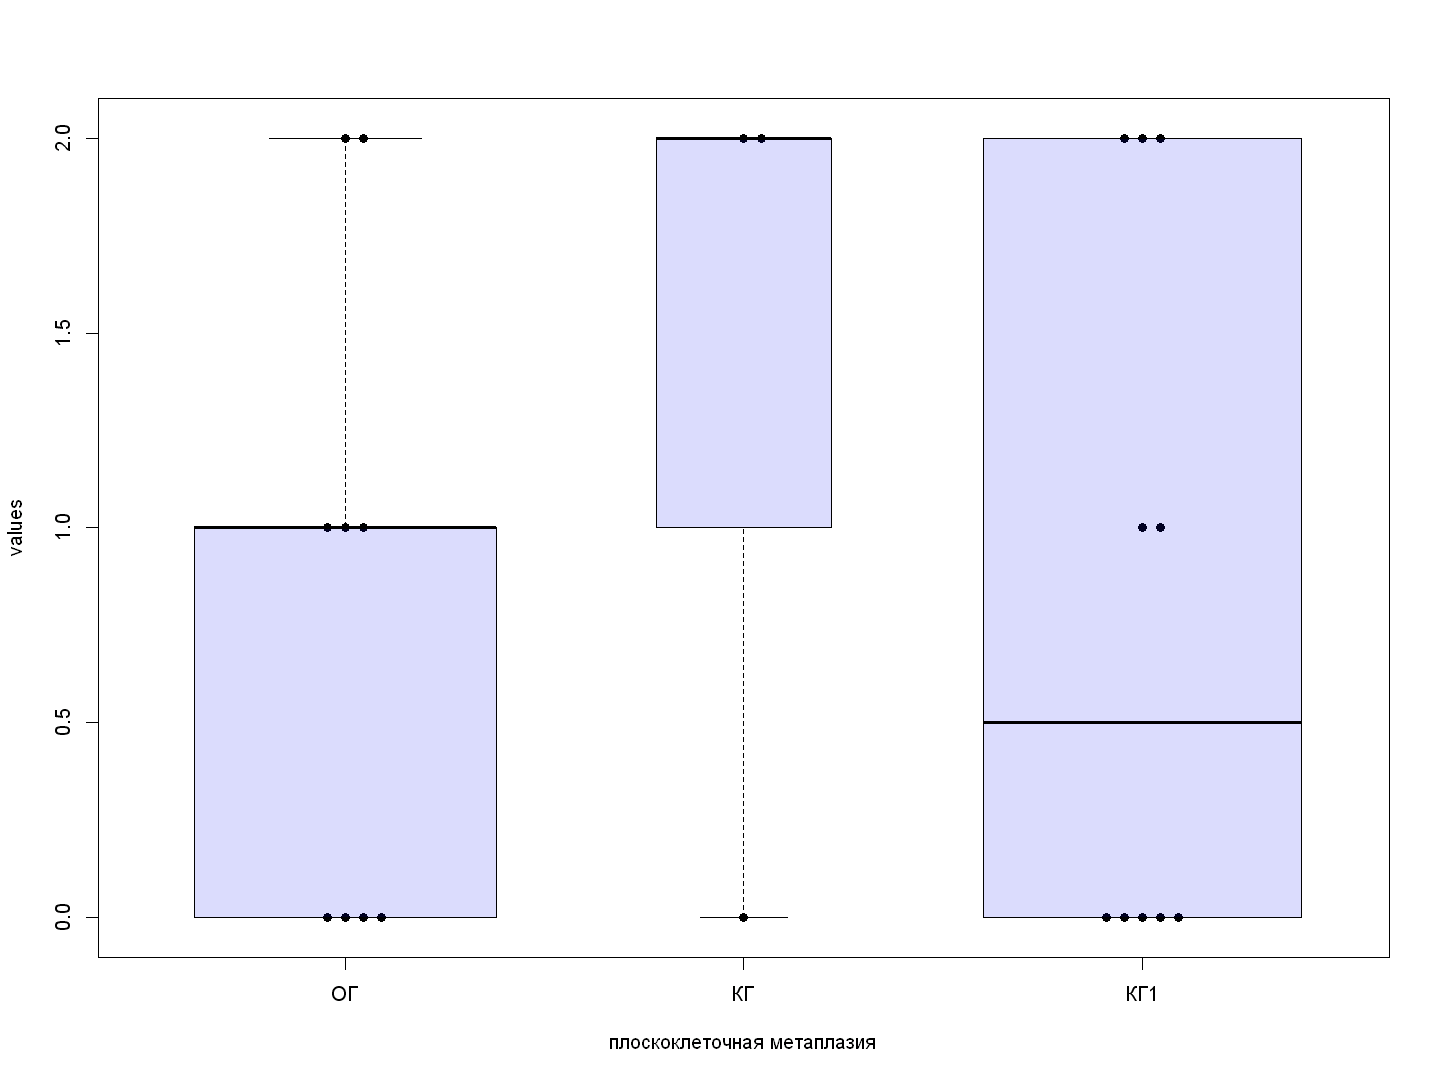

In [49]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [50]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.85853, df = 2, p-value = 0.651

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
       obs.dif critical.dif stat.signif
ОГ-КГ     3.50    10.363677       FALSE
ОГ-КГ1    0.05     7.142671       FALSE
КГ-КГ1    3.45    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 9, p-value = 0.4307
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -0.88641, p-value = 0.4727
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 45, p-value = 1
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parnam

## эозинофилы

### Общее

In [51]:
parname <- "эозинофилы"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [52]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [53]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean       sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.5555556 1.130388   0  0   0   0   0    3      9
КГ  0.0000000 0.000000   0  0   0   0   0    0      3
КГ1 0.0000000 0.000000   0  0   0   0   0    0     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,3,0.5555556,1.130388,9,0
КГ,0,0,0,0,0,0.0000000,0.000000,3,0
КГ1,0,0,0,0,0,0.0000000,0.000000,10,0


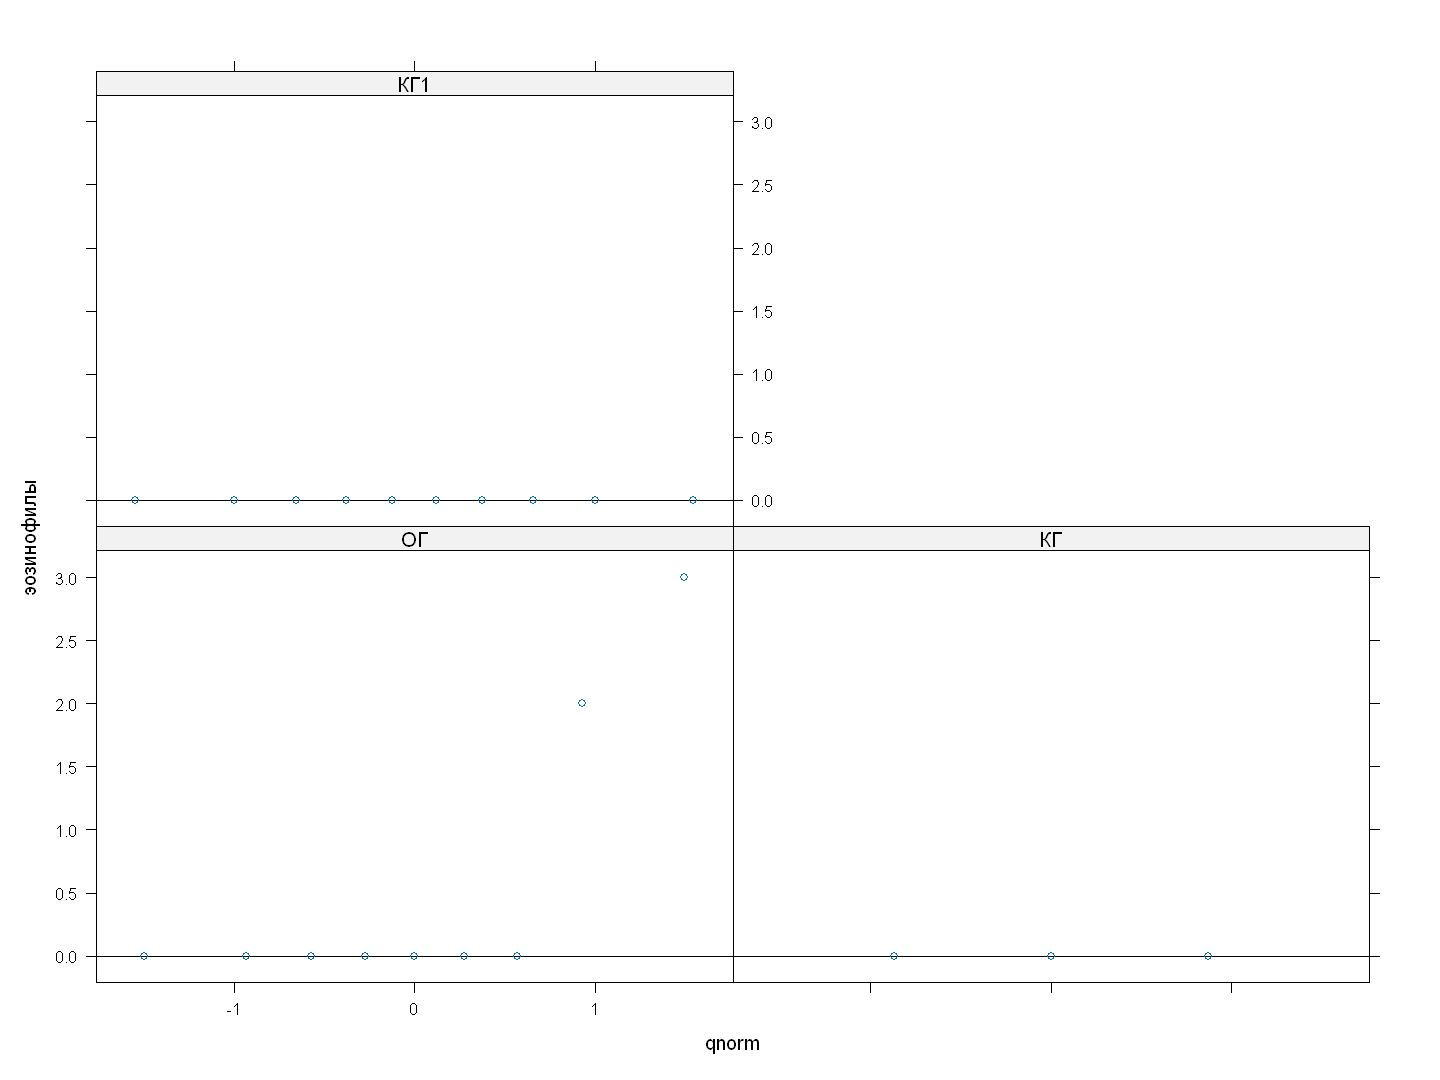

In [54]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

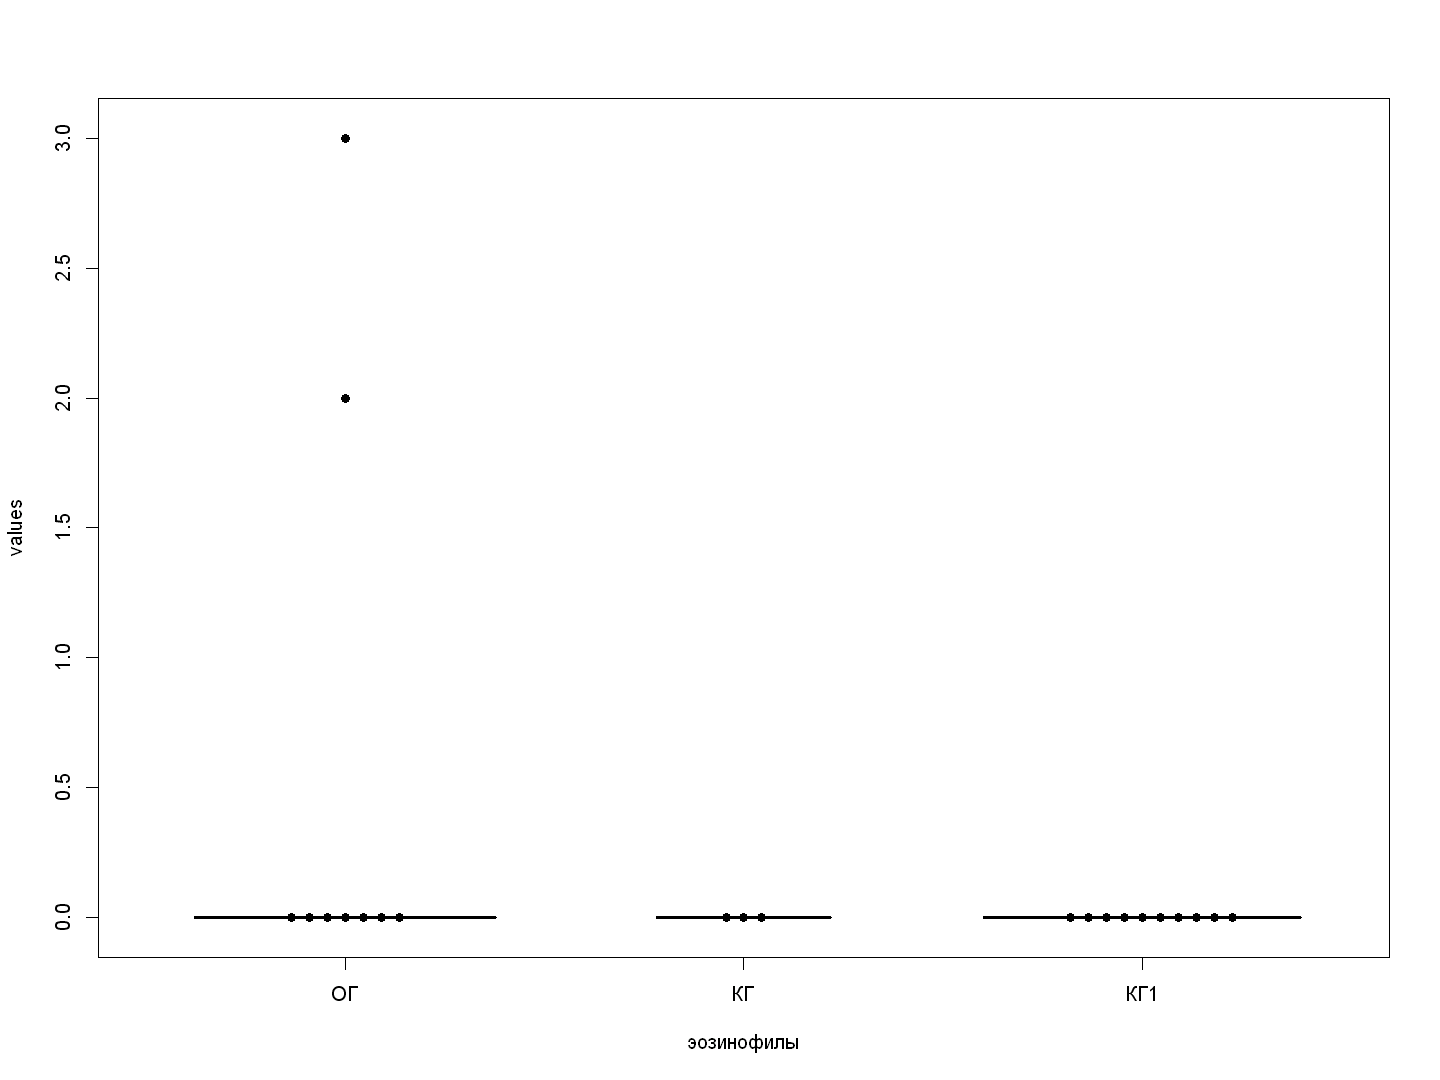

In [55]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [56]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 3.0265, df = 2, p-value = 0.2202

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  2.444444    10.363677       FALSE
ОГ-КГ1 2.444444     7.142671       FALSE
КГ-КГ1 0.000000    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 16.5, p-value = 0.4773
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 0.8528, p-value = 0.7955
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 55, p-value = 0.1457
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  

## нейтрофилы

### Общее

In [57]:
parname <- "нейтрофилы"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [58]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [59]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.1111111 0.3333333   0  0   0   0   0    1      9
КГ  0.0000000 0.0000000   0  0   0   0   0    0      3
КГ1 0.0000000 0.0000000   0  0   0   0   0    0     10

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,1,0.1111111,0.3333333,9,0
КГ,0,0,0,0,0,0.0000000,0.0000000,3,0
КГ1,0,0,0,0,0,0.0000000,0.0000000,10,0


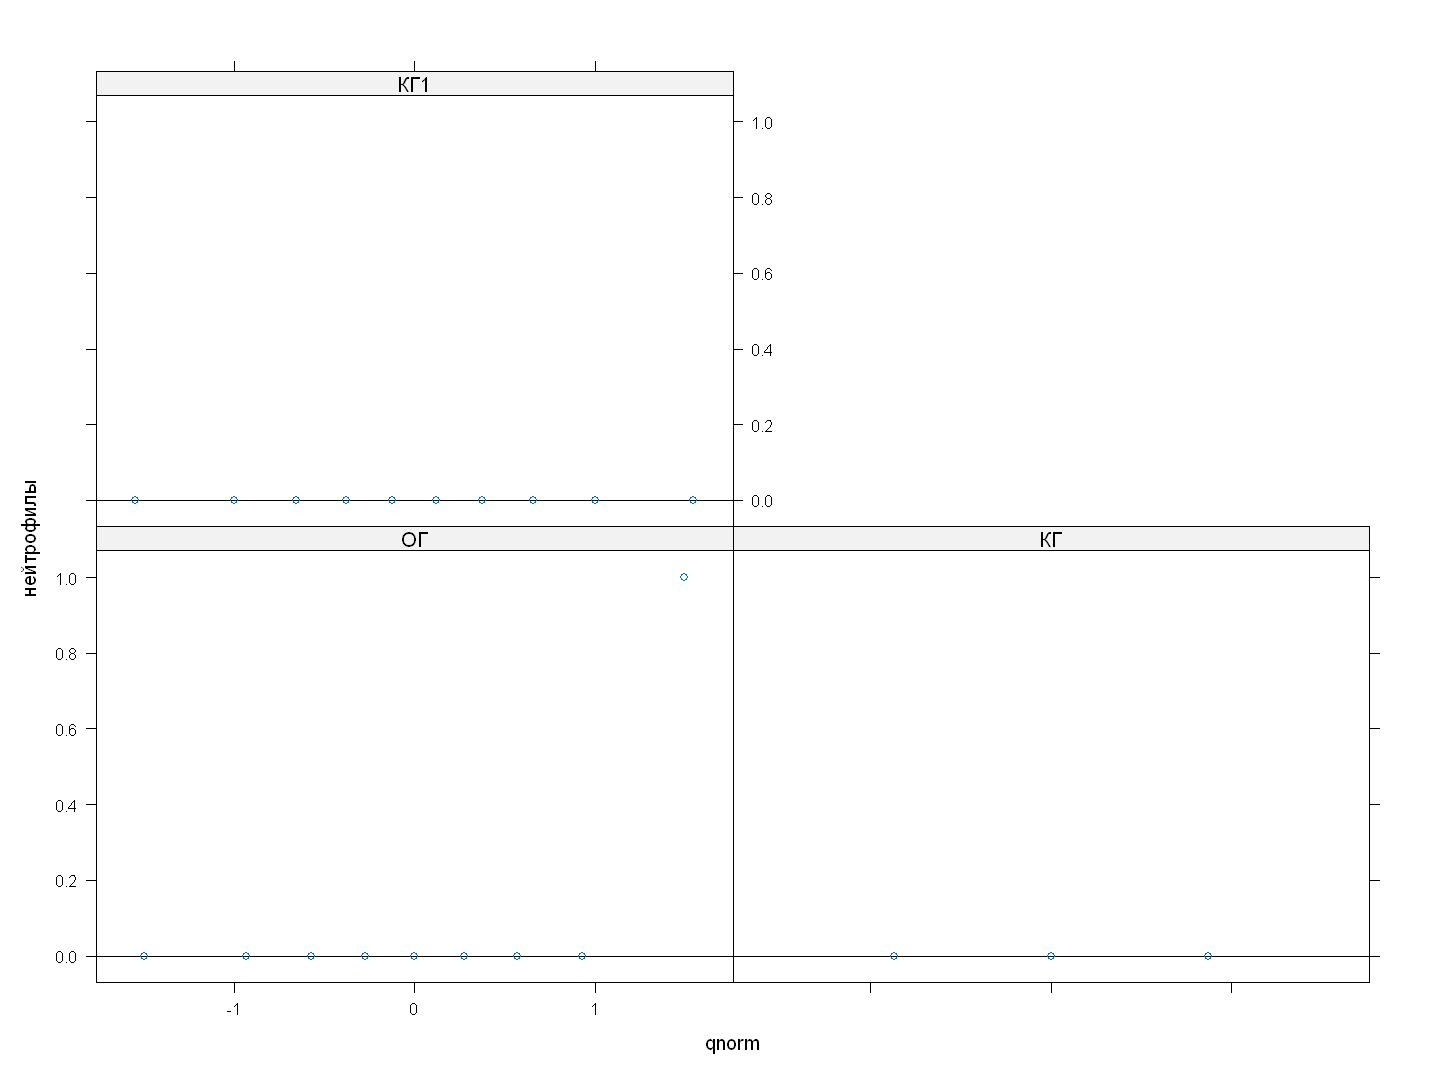

In [60]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

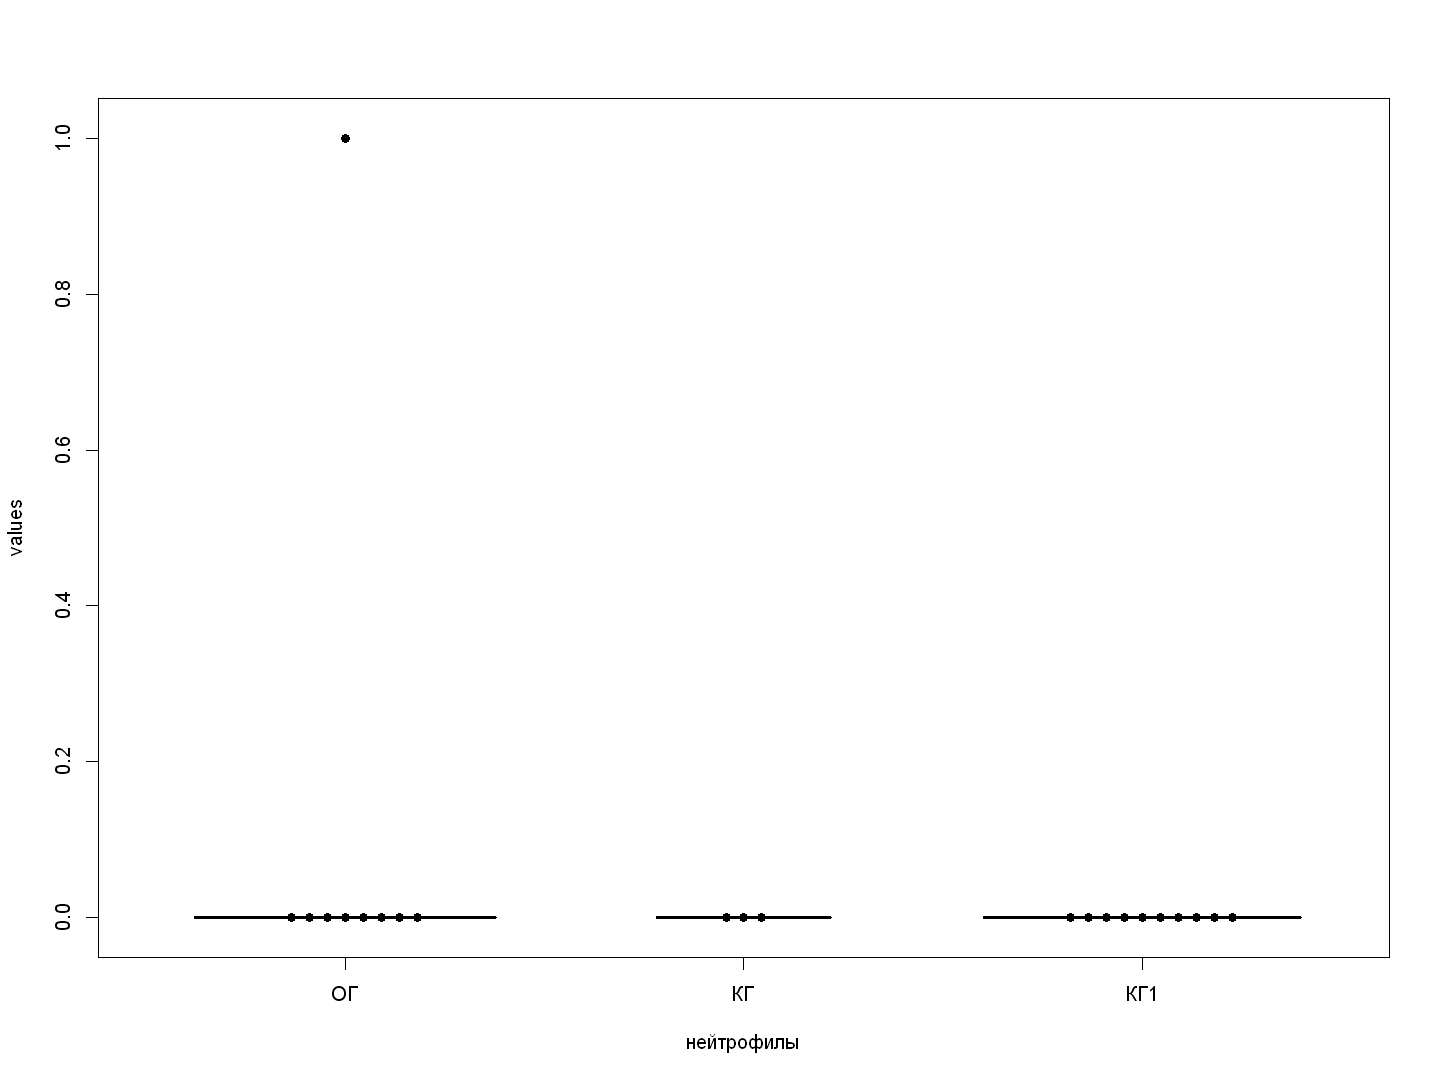

In [61]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [62]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.4444, df = 2, p-value = 0.4857

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  1.222222    10.363677       FALSE
ОГ-КГ1 1.222222     7.142671       FALSE
КГ-КГ1 0.000000    10.233311       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 15, p-value = 0.7003
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 0.57735, p-value = 1
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 50, p-value = 0.3428
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[pa